In [1]:
%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=107d68b3fec0eccafe35133ce14b837ab67668a2b589db73f3e1552439c91ae1
  Stored in directory: /tmp/pip-ephem-wheel-cache-038ytvay/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
import  os
import  json
import  pandas as pd
import  numpy as np
import  joblib
import  thermoift.PLOT_SETTINGS as ps
from    thermoift import MLPostprocessing, MLPreprocessing
from    thermoift.rng_utils import get_rng
from    thermoift import plot_correlation_heatmap, print_model_metrics
from    sklearn.preprocessing import StandardScaler
from    sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from    sklearn.gaussian_process import GaussianProcessRegressor
from    sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from    sklearn.pipeline import Pipeline
from    sklearn.metrics import r2_score as _r2

In [3]:
OUTPUT_FOLDER           = "GPR_RESIDUAL_OUTPUTS"
SEED                    = 4555525
EXPERIMENT_MAX_SAMPLES  = 2000  # Set to None to use the full dataset
RESTART_OPTIMIZER       = 1

# Cross-validation settings
RUN_CV                  = False  # set False to skip (saves ~10 min on full dataset)
CV_FOLDS                = 5

In [4]:
df          = pd.read_csv("1691761_CombinedDataset_A3.csv")
df.columns  = [col.strip().replace(" ", "_") for col in df.columns]

# Mixture CO2 partial density gap
df["NUM1"]  = df["rhoL_carbon_dioxide"] - df["rhoV_carbon_dioxide"]
df["DEN1"]  = df["rhoL0_carbon_dioxide"] - df["rhoV0_carbon_dioxide"]

# Reference density-gap ratio
df["r1"]    = df["NUM1"] / df["DEN1"]
df["r1sq"]  = df["r1"] ** 2

# WSD baseline if only CO2 contributes
# gamma_base = gamma0_CO2 * r1^2
df["gamma_base"] = df["gamma0_carbon_dioxide"] * df["r1sq"]
df["gamma_cDFT"] = df["gamma_wsd"] + df["gamma_cDFT_minus_wsd_uncorrected"]

# Target : Relative residual vs baseline
df             = df.dropna(subset=["gamma_cDFT", "gamma_base"]).copy()
df["residual"] = df["gamma_cDFT"] - df["gamma_base"]

if EXPERIMENT_MAX_SAMPLES is not None:
    # Stratified sampling over T–P bins to guarantee coverage of rare regions
    df["_T_bin"]    = pd.qcut(df["T"], q=10, labels=False, duplicates="drop")
    df["_P_bin"]    = pd.qcut(df["P"], q=10, labels=False, duplicates="drop")
    df["_stratum"]  = df["_T_bin"].astype(str) + "_" + df["_P_bin"].astype(str)
    n_target        = min(EXPERIMENT_MAX_SAMPLES, len(df))
    df = (
        df.groupby("_stratum", group_keys=False)
          .apply(lambda g: g.sample(
              n=max(1, round(n_target * len(g) / len(df))),
              random_state=SEED,
          ))
          .sample(frac=1, random_state=SEED)  # shuffle
          .head(n_target)                     # exact cap
          .drop(columns=["_T_bin", "_P_bin", "_stratum"])
          .reset_index(drop=True)
    )

print(f"Total active samples: {len(df)}")
print(f"Experiment sample cap: {EXPERIMENT_MAX_SAMPLES}")
print(f"Residual statistics:")
print(df["residual"].describe())


Total active samples: 2000
Experiment sample cap: 2000
Residual statistics:
count    2000.000000
mean       -0.381477
std         0.784425
min        -4.407020
25%        -0.609245
50%        -0.229135
75%        -0.052292
max         5.634033
Name: residual, dtype: float64


/tmp/ipykernel_2492732/525393716.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(


In [5]:
target          = "residual"
rng             = get_rng(seed=SEED)

z_columns       = [col for col in df.columns if col.startswith("z_")]
DROP_FEATURES   = ["z_oxygen"]
Z_non_zero      = [col for col in z_columns if (df[col] != 0).any() and col not in DROP_FEATURES]
features        = ["T", "P"] + Z_non_zero

print(f"Selected features: {features}")

X               = df[features]
y               = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp    = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val        = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

# Working dataframe has already been reduced above when EXPERIMENT_MAX_SAMPLES is set

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:      {X_test.shape[0]}")
print(f"Validation samples:   {X_val.shape[0]}")

Selected features: ['T', 'P', 'z_argon', 'z_carbon_dioxide', 'z_carbon_monoxide', 'z_hydrogen', 'z_hydrogen_sulfide', 'z_methane', 'z_nitrogen']

Training samples:   1400
Testing samples:      300
Validation samples:   300


Feature correlations with residual:
z_hydrogen_sulfide    0.501976
T                     0.351959
z_carbon_dioxide      0.174849
z_methane            -0.019065
P                    -0.069927
z_nitrogen           -0.138223
z_argon              -0.168265
z_carbon_monoxide    -0.202579
z_hydrogen           -0.266250
Name: residual, dtype: float64


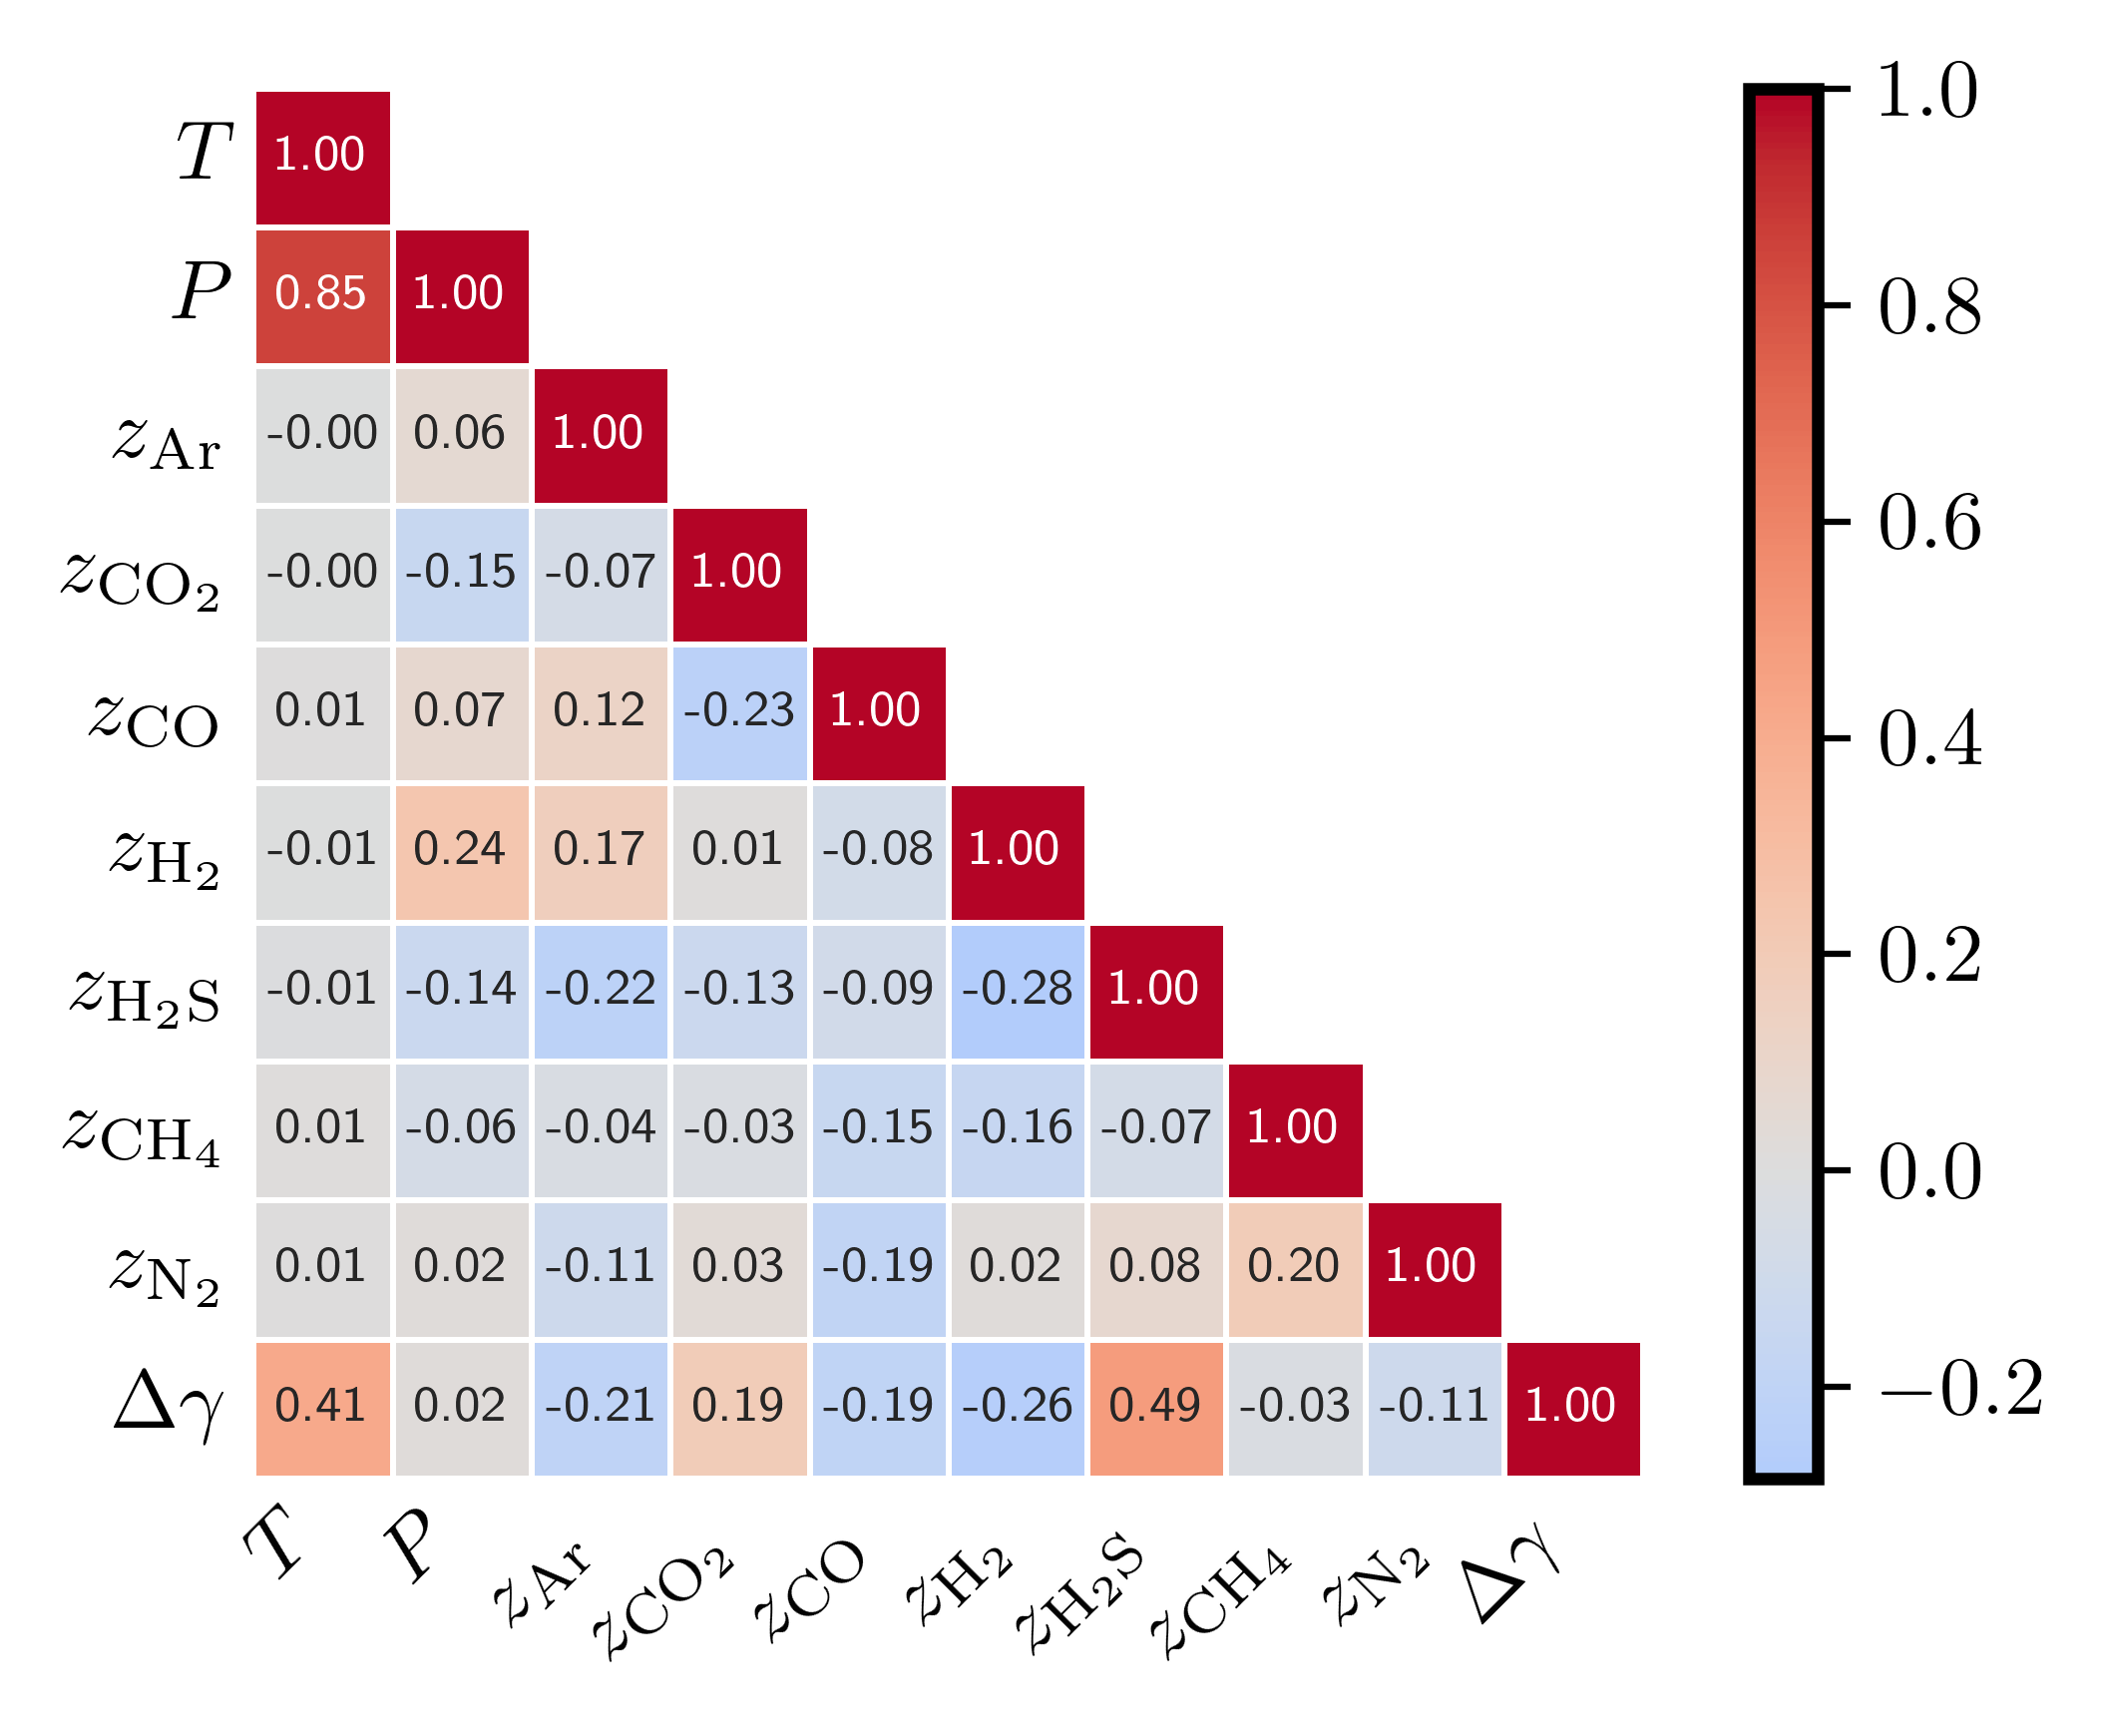

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [6]:
plot_correlation_heatmap(df, features, target, save_path="GPR_residual_correlation", folder=OUTPUT_FOLDER)

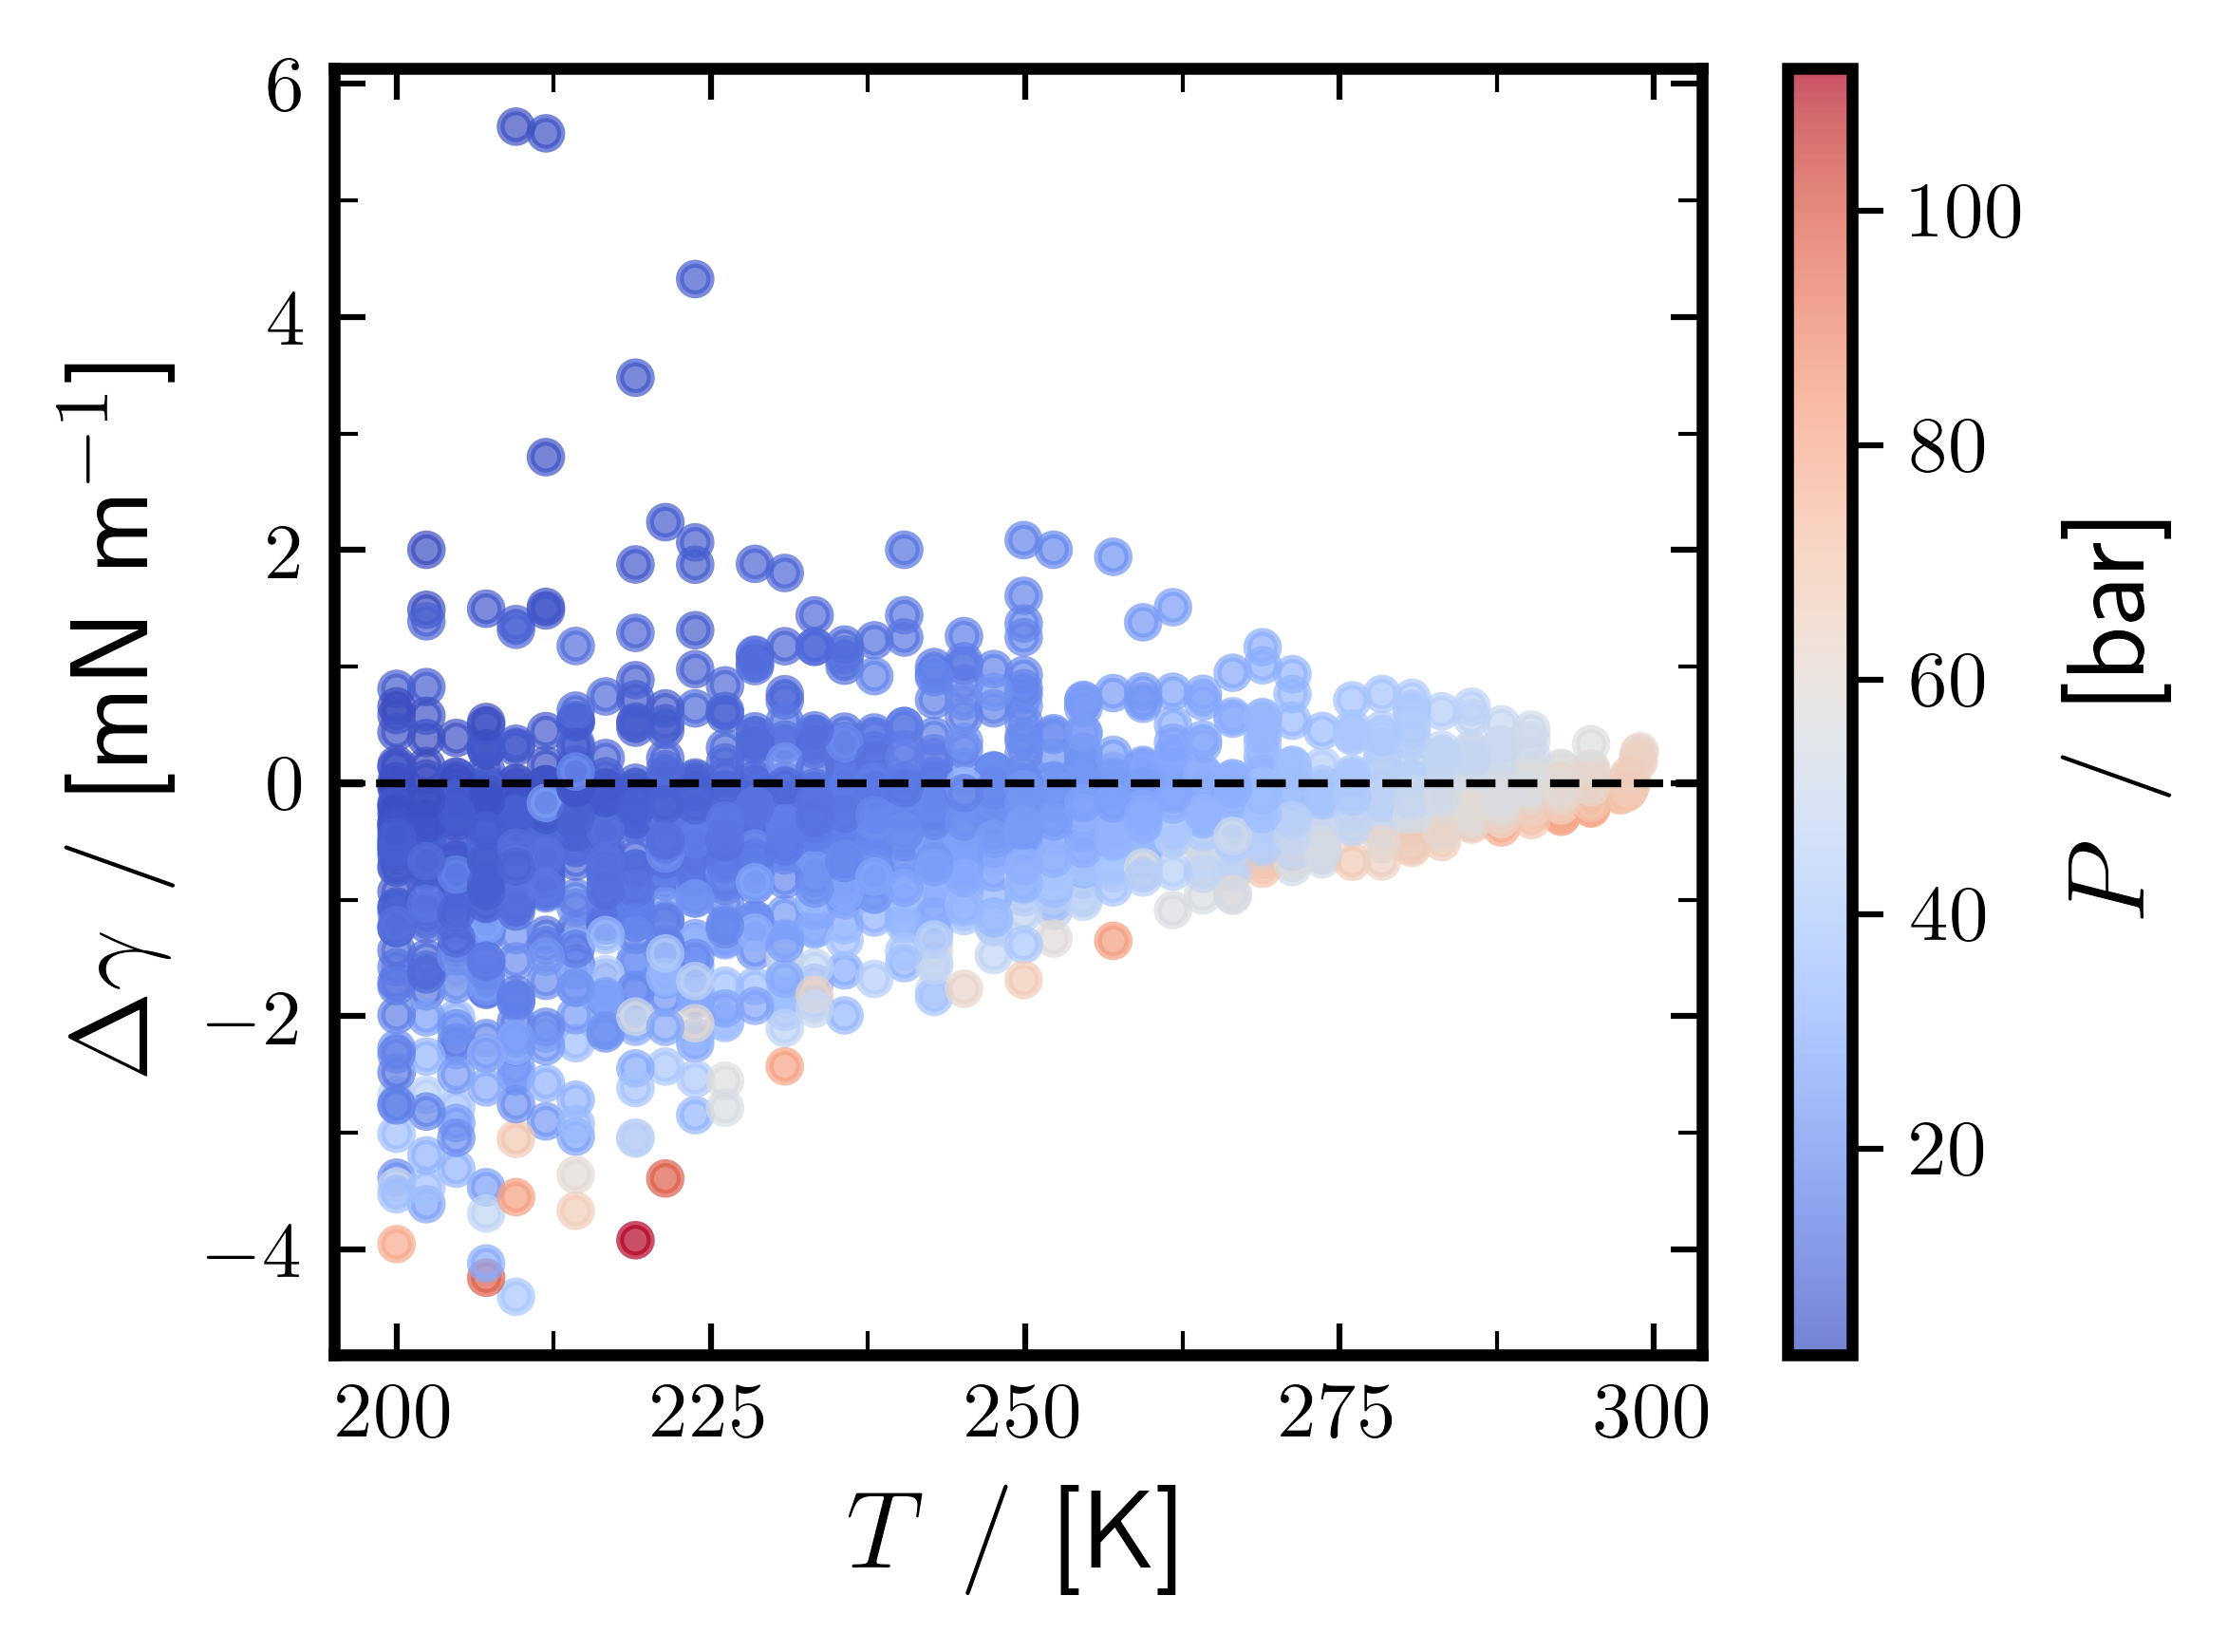

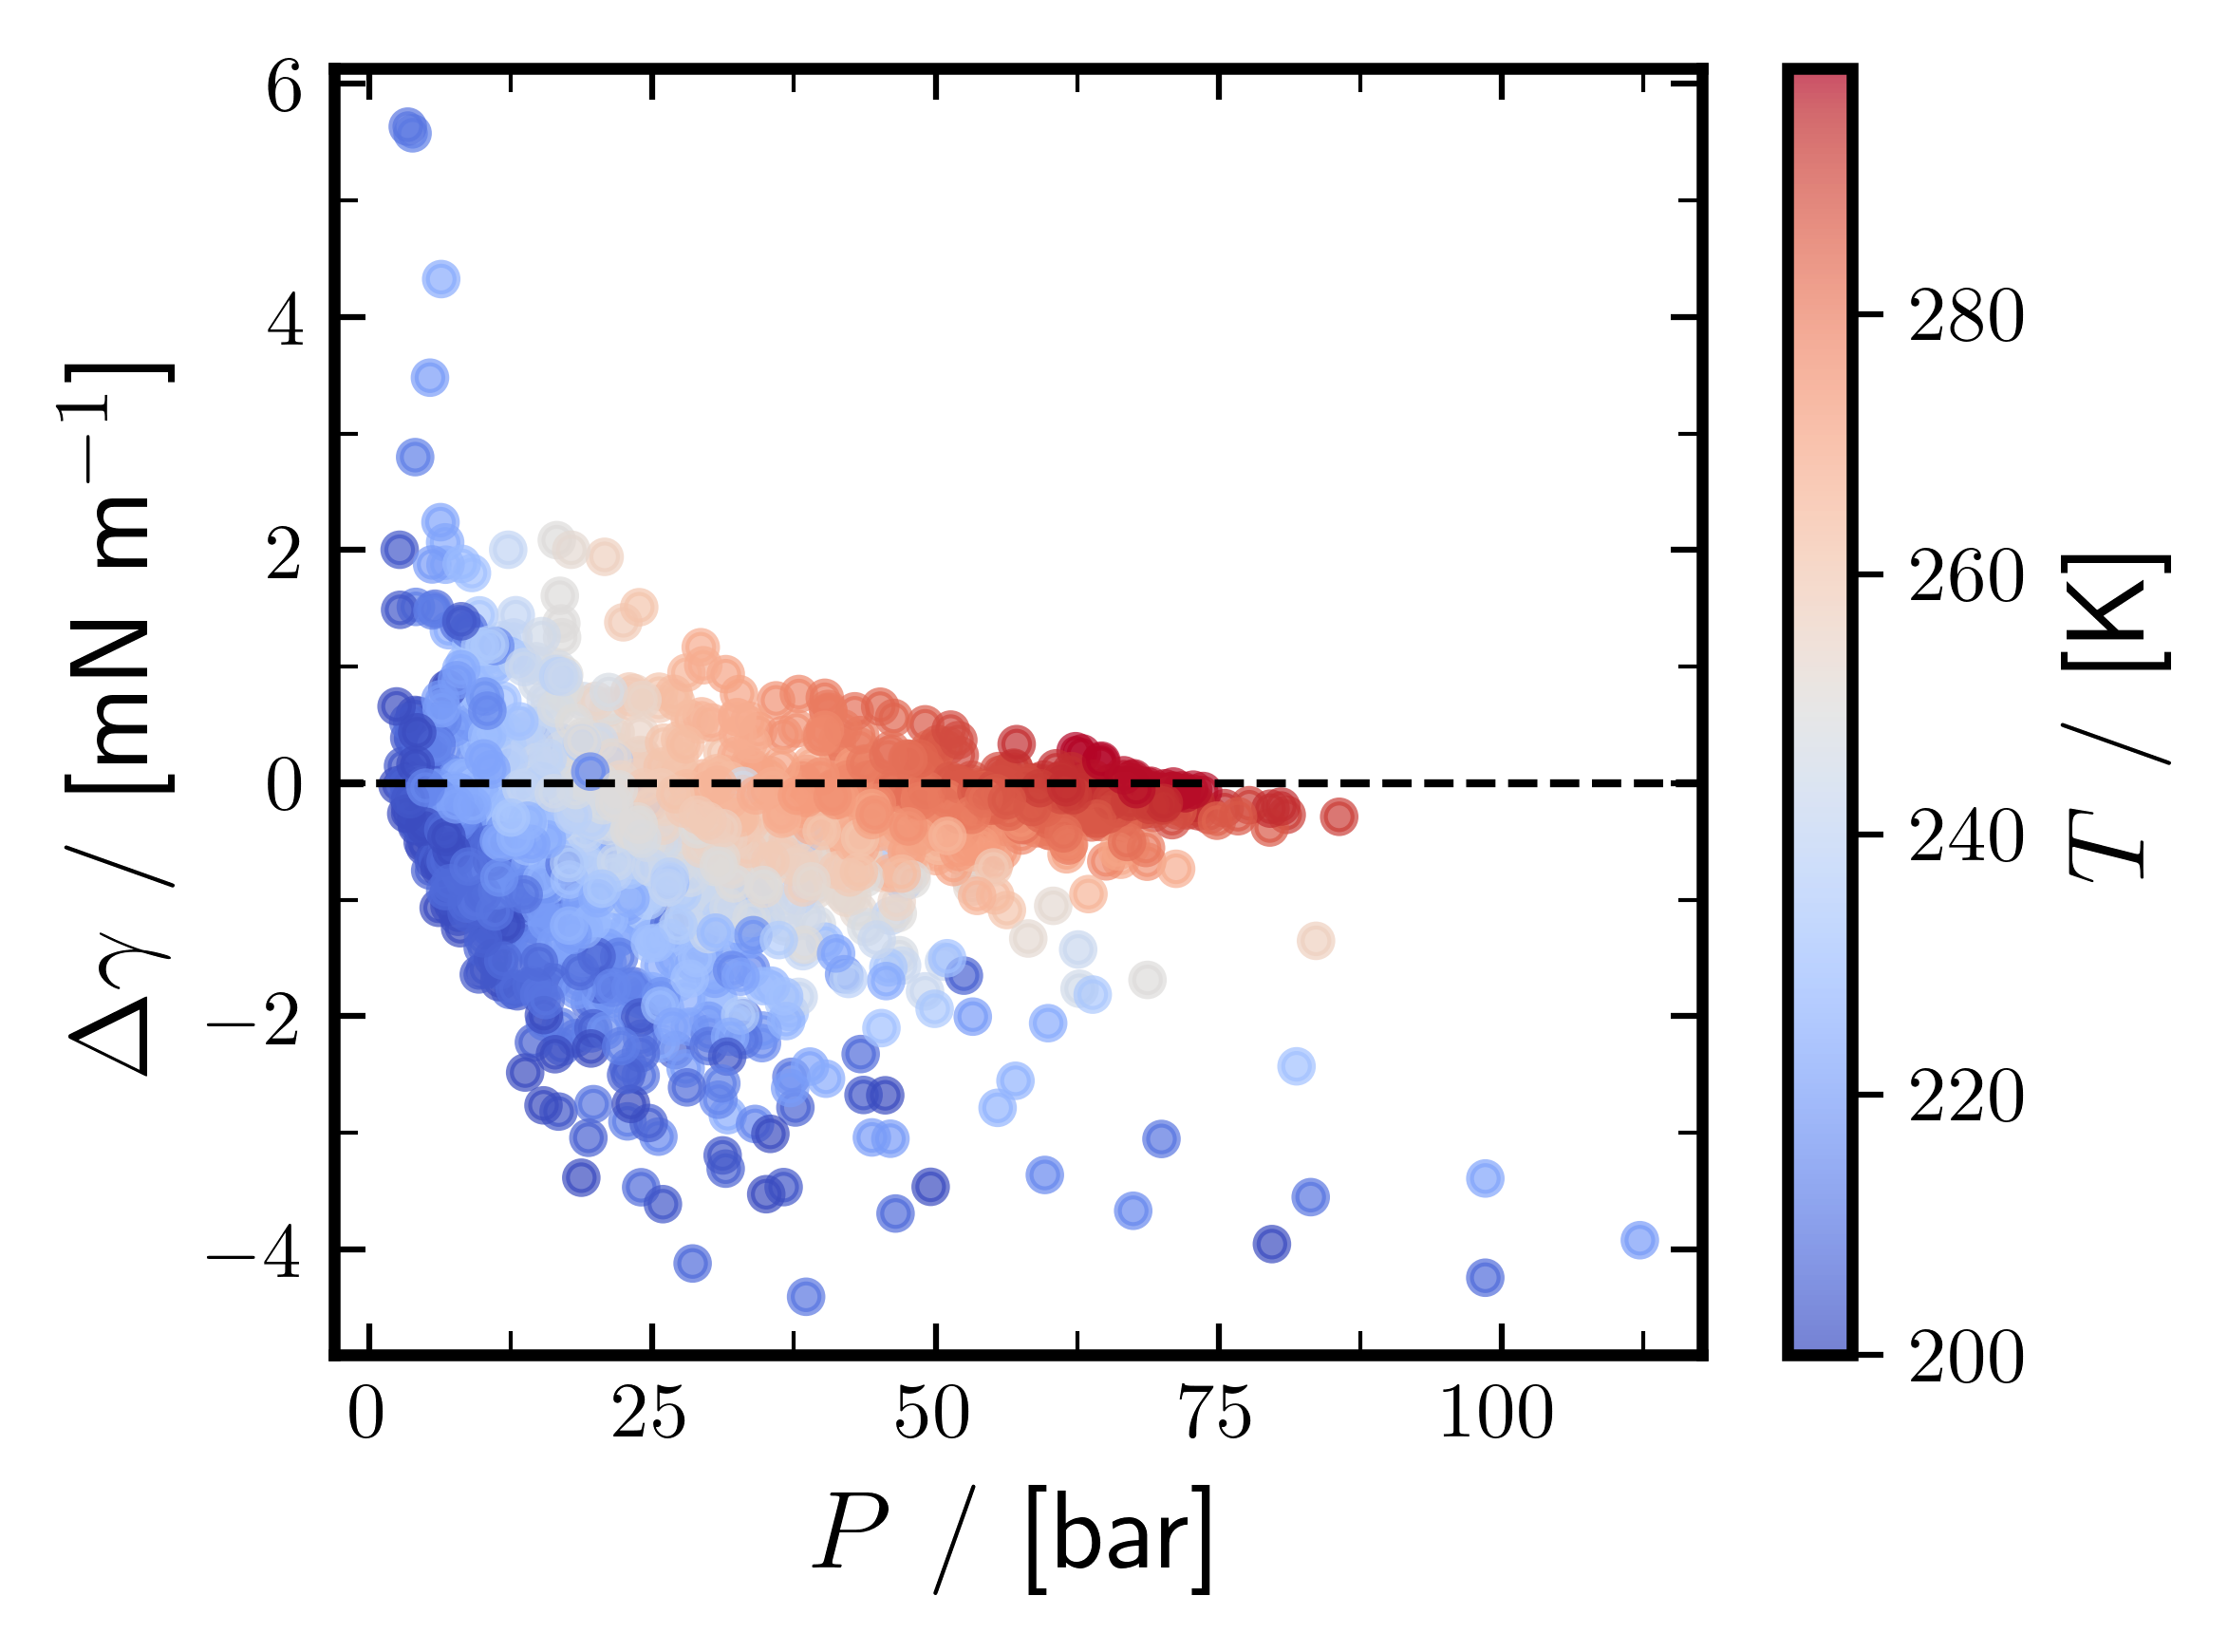

(<Figure size 2400x1800 with 2 Axes>,
 <Axes: xlabel='$P$ / [bar]', ylabel='$\\Delta \\gamma$ / [mN m$^{-1}$]'>)

In [7]:
prep = MLPreprocessing(df=df, features=features, target=target)

prep.plot_scatter(
    x           = "T",
    y           = target,
    color_by    = "P",
    hline       = 0.0,
    save_path   = "GPR_residual_vs_T",
    folder      = OUTPUT_FOLDER,
)

prep.plot_scatter(
    x           = "P",
    y           = target,
    color_by    = "T",
    hline       = 0.0,
    save_path   = "GPR_residual_vs_P",
    folder      = OUTPUT_FOLDER,
)

In [8]:
# ── Baseline over/underprediction inspection ─────────────────────────────────
# Δγ < 0  →  baseline OVERpredicts  γ_cDFT  (most negative residuals)
# Δγ > 0  →  baseline UNDERpredicts γ_cDFT  (most positive residuals)
N = 10

z_cols    = [c for c in features if c.startswith("z_")]
z_non_co2 = [c for c in z_cols if c != "z_carbon_dioxide"]

inspect = df[features + [target]].copy()
inspect["source_id"]        = df["source_id"].values
inspect["dominant_species"] = inspect[z_non_co2].idxmax(axis=1).str.replace("z_", "")

cols_out = ["source_id", "dominant_species", "T", "P", target]

print(f"Top-{N} BASELINE OVERPREDICTIONS  (Δγ most negative — baseline too high):")
print(inspect.nsmallest(N, target)[cols_out].to_string(index=False))

print(f"Top-{N} BASELINE UNDERPREDICTIONS (Δγ most positive — baseline too low):")
print(inspect.nlargest(N, target)[cols_out].to_string(index=False))


Top-10 BASELINE OVERPREDICTIONS  (Δγ most negative — baseline too high):
 source_id dominant_species       T          P  residual
         1         nitrogen 209.500  38.569759 -4.407020
        74         hydrogen 207.125  98.538044 -4.243447
        80  carbon_monoxide 207.125  28.550452 -4.121232
        81         hydrogen 200.000  79.700585 -3.955029
        74         hydrogen 219.000 112.185571 -3.921492
        23         hydrogen 207.125  46.467416 -3.692646
        42         hydrogen 214.250  67.451873 -3.668959
        10  carbon_monoxide 202.375  25.927248 -3.612213
        83         hydrogen 209.500  83.124085 -3.551992
        23         hydrogen 200.000  35.050889 -3.526826
Top-10 BASELINE UNDERPREDICTIONS (Δγ most positive — baseline too low):
 source_id dominant_species       T         P  residual
        86 hydrogen_sulfide 209.500  3.399617  5.634033
        76 hydrogen_sulfide 211.875  3.824216  5.576556
        86 hydrogen_sulfide 223.750  6.352849  4.326028
    

In [9]:
print(df[["gamma_cDFT", "gamma_base", "residual"]].isna().sum())
print("Any NaN in X:", X.isna().any().any())
print("Any NaN in y:", y.isna().any())

gamma_cDFT    0
gamma_base    0
residual      0
dtype: int64
Any NaN in X: False
Any NaN in y: False


In [10]:
# Kernel 
#Choice1: const * RBF + WhiteKernel
n_features = X_train.shape[1]
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3)) *
    RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-2, 1e3)) +
    WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e0))
)

# Pipeline
gpr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(
        kernel      = kernel,
        alpha       = 0.0,
        normalize_y = True,
        n_restarts_optimizer = RESTART_OPTIMIZER,
        random_state         = SEED,
    ))
]) 

# Fit
gpr_model.fit(X_train, y_train)

# Predictions
y_train_pred, y_train_std   = gpr_model.predict(X_train, return_std=True)
y_val_pred, y_val_std       = gpr_model.predict(X_val, return_std=True)
y_test_pred, y_test_std     = gpr_model.predict(X_test, return_std=True)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, unit="mN/m", y_val=y_val, y_val_pred=y_val_pred)

Model Performance for residual

Training Set:
  R²:   0.995408
  RMSE: 0.050372 mN/m
  MAE:  0.023042 mN/m

Test Set:
  R²:   0.954657
  RMSE: 0.176722 mN/m
  MAE:  0.056572 mN/m

Validation Set:
  R²:   0.920931
  RMSE: 0.255711 mN/m
  MAE:  0.052733 mN/m


In [11]:
# 5-fold stratified cross-validation (same T-P binning used during sampling)
if RUN_CV:
    # Re-create stratum labels from X so each fold mirrors the T-P coverage
    _T_bin_cv = pd.qcut(X["T"], q=10, labels=False, duplicates="drop")
    _P_bin_cv = pd.qcut(X["P"], q=10, labels=False, duplicates="drop")
    _strata   = _T_bin_cv.astype(str) + "_" + _P_bin_cv.astype(str)

    _skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

    cv_r2_scores   = cross_val_score(gpr_model, X, y, cv=_skf.split(X, _strata), scoring='r2')
    cv_rmse_scores = -cross_val_score(gpr_model, X, y, cv=_skf.split(X, _strata), scoring='neg_root_mean_squared_error')

    print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
    print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
    print(f"Cross-Validation RMSE Scores: {cv_rmse_scores}")
    print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
else:
    cv_r2_scores   = np.array([])
    cv_rmse_scores = np.array([])
    print("CV skipped (RUN_CV=False).")

CV skipped (RUN_CV=False).


In [12]:
# Initialize MLPostprocessing
# GPR ARD feature importance: inverse length scales from the RBF kernel
# Kernel structure: (ConstantKernel * RBF) + WhiteKernel -> k1.k2.length_scale
_length_scales          = gpr_model.named_steps["gpr"].kernel_.k1.k2.length_scale
_feature_importances    = 1.0 / _length_scales
_feature_importances    = _feature_importances / _feature_importances.sum()  # normalize

post = MLPostprocessing(
    y_true  =y_test,
    y_pred  =y_test_pred,
    target  ="delta_gamma",
    feature_importances =_feature_importances,
    feature_names       =features,
    datasets            ={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

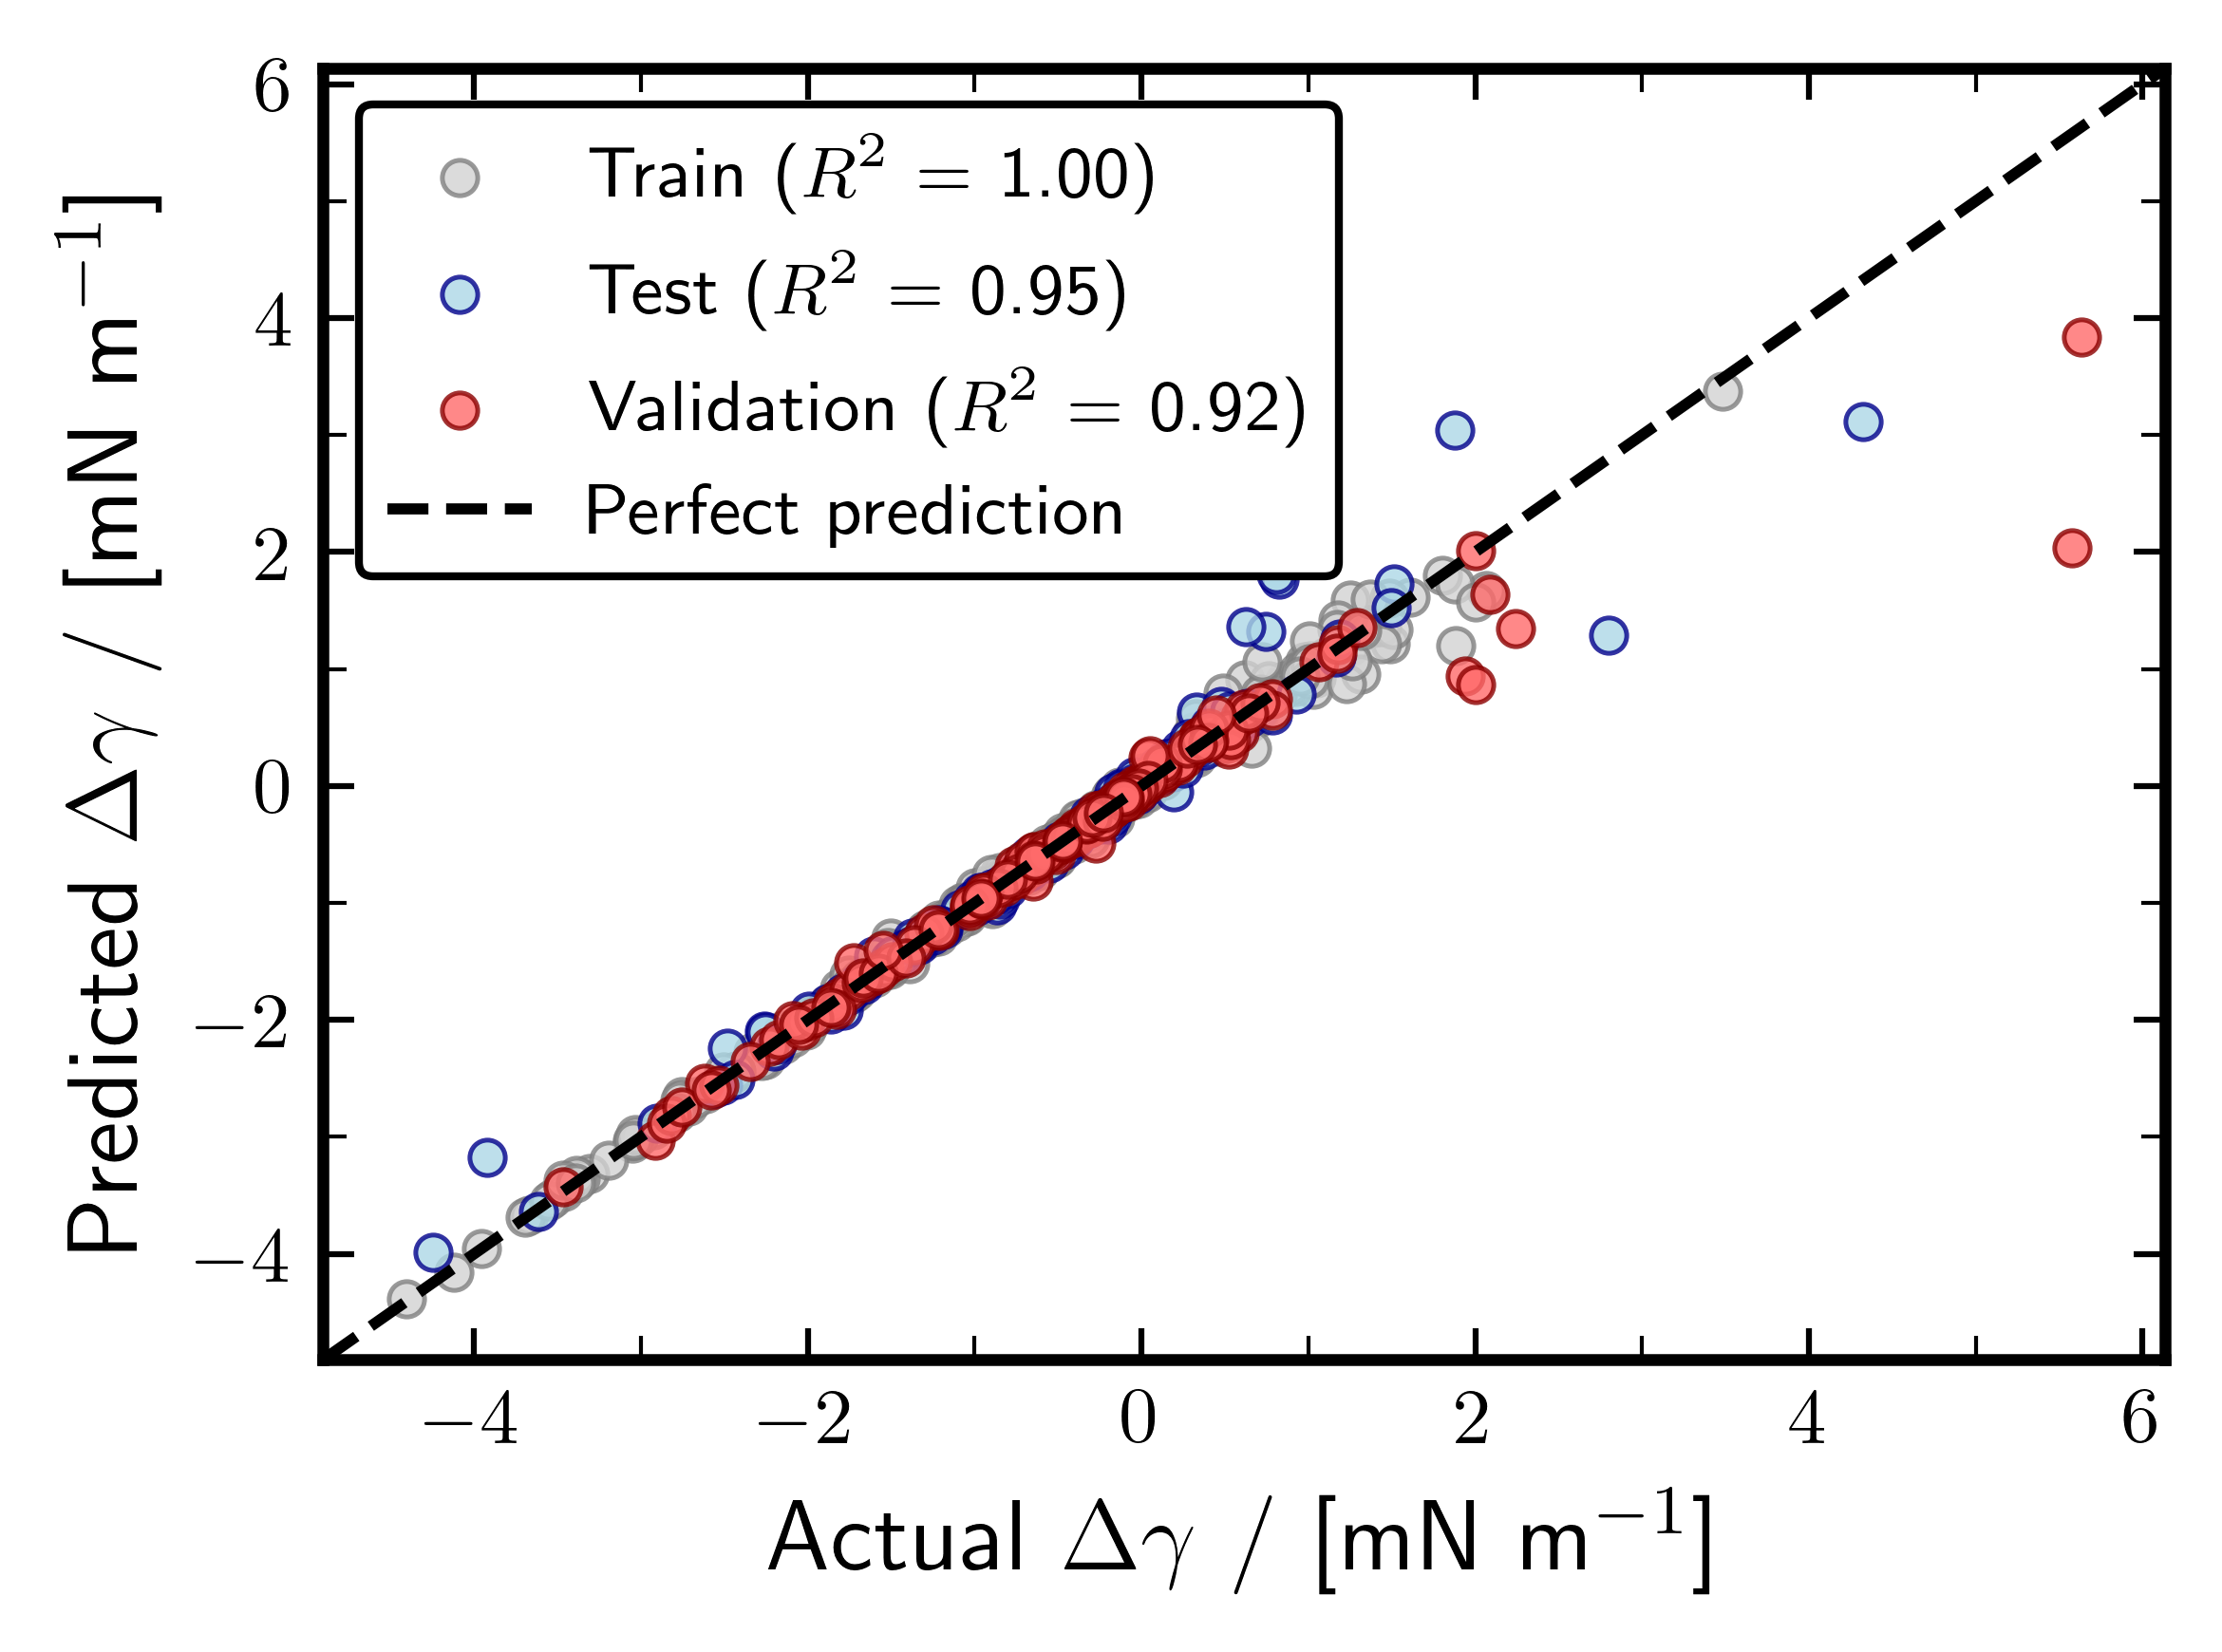

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $\\Delta\\gamma$ / [mN m$^{-1}$]', ylabel='Predicted $\\Delta\\gamma$ / [mN m$^{-1}$]'>)

In [13]:
# Parity plot
post.plot_parity(model_name="GPR (RBF)", save_path="GPR_gamma_parity_plot", folder=OUTPUT_FOLDER)

In [14]:
# ── Validation outlier inspection ────────────────────────────────────────────
N_OUTLIERS = 10

z_cols    = [c for c in features if c.startswith("z_")]
z_non_co2 = [c for c in z_cols if c != "z_carbon_dioxide"]

val_df = X_val.copy()
val_df["y_true"]           = y_val.values
val_df["y_pred"]           = y_val_pred
val_df["error"]            = y_val_pred - y_val.values
val_df["abs_err"]          = val_df["error"].abs()
val_df["source_id"]        = df.loc[val_df.index, "source_id"].values
val_df["dominant_species"] = val_df[z_non_co2].idxmax(axis=1).str.replace("z_", "")

outliers = val_df.nlargest(N_OUTLIERS, "abs_err")[
    ["source_id", "dominant_species", "T", "P", "y_true", "y_pred", "error"]
]

print(f"Top-{N_OUTLIERS} validation outliers (sorted by |error|):")
print(outliers.to_string(index=False))


Top-10 validation outliers (sorted by |error|):
 source_id dominant_species       T         P    y_true    y_pred     error
        76 hydrogen_sulfide 211.875  3.824216  5.576556  2.037125 -3.539432
        86 hydrogen_sulfide 209.500  3.399617  5.634033  3.838008 -1.796025
         7          methane 202.375  2.685000  2.003249  0.868602 -1.134647
        76 hydrogen_sulfide 257.000 20.781460  1.942357  0.941113 -1.001244
        72  carbon_monoxide 221.375  6.288071  2.239972  1.344468 -0.895504
        86 hydrogen_sulfide 249.875 16.558836  2.085564  1.640239 -0.445325
        42         hydrogen 204.750 20.364549 -1.726300 -1.510539  0.215761
         7          methane 214.250 12.392502 -0.275651 -0.487984 -0.212333
        62  carbon_monoxide 207.125  3.438769  0.525026  0.316627 -0.208400
         8         nitrogen 204.750  4.786225  0.050248  0.256661  0.206414


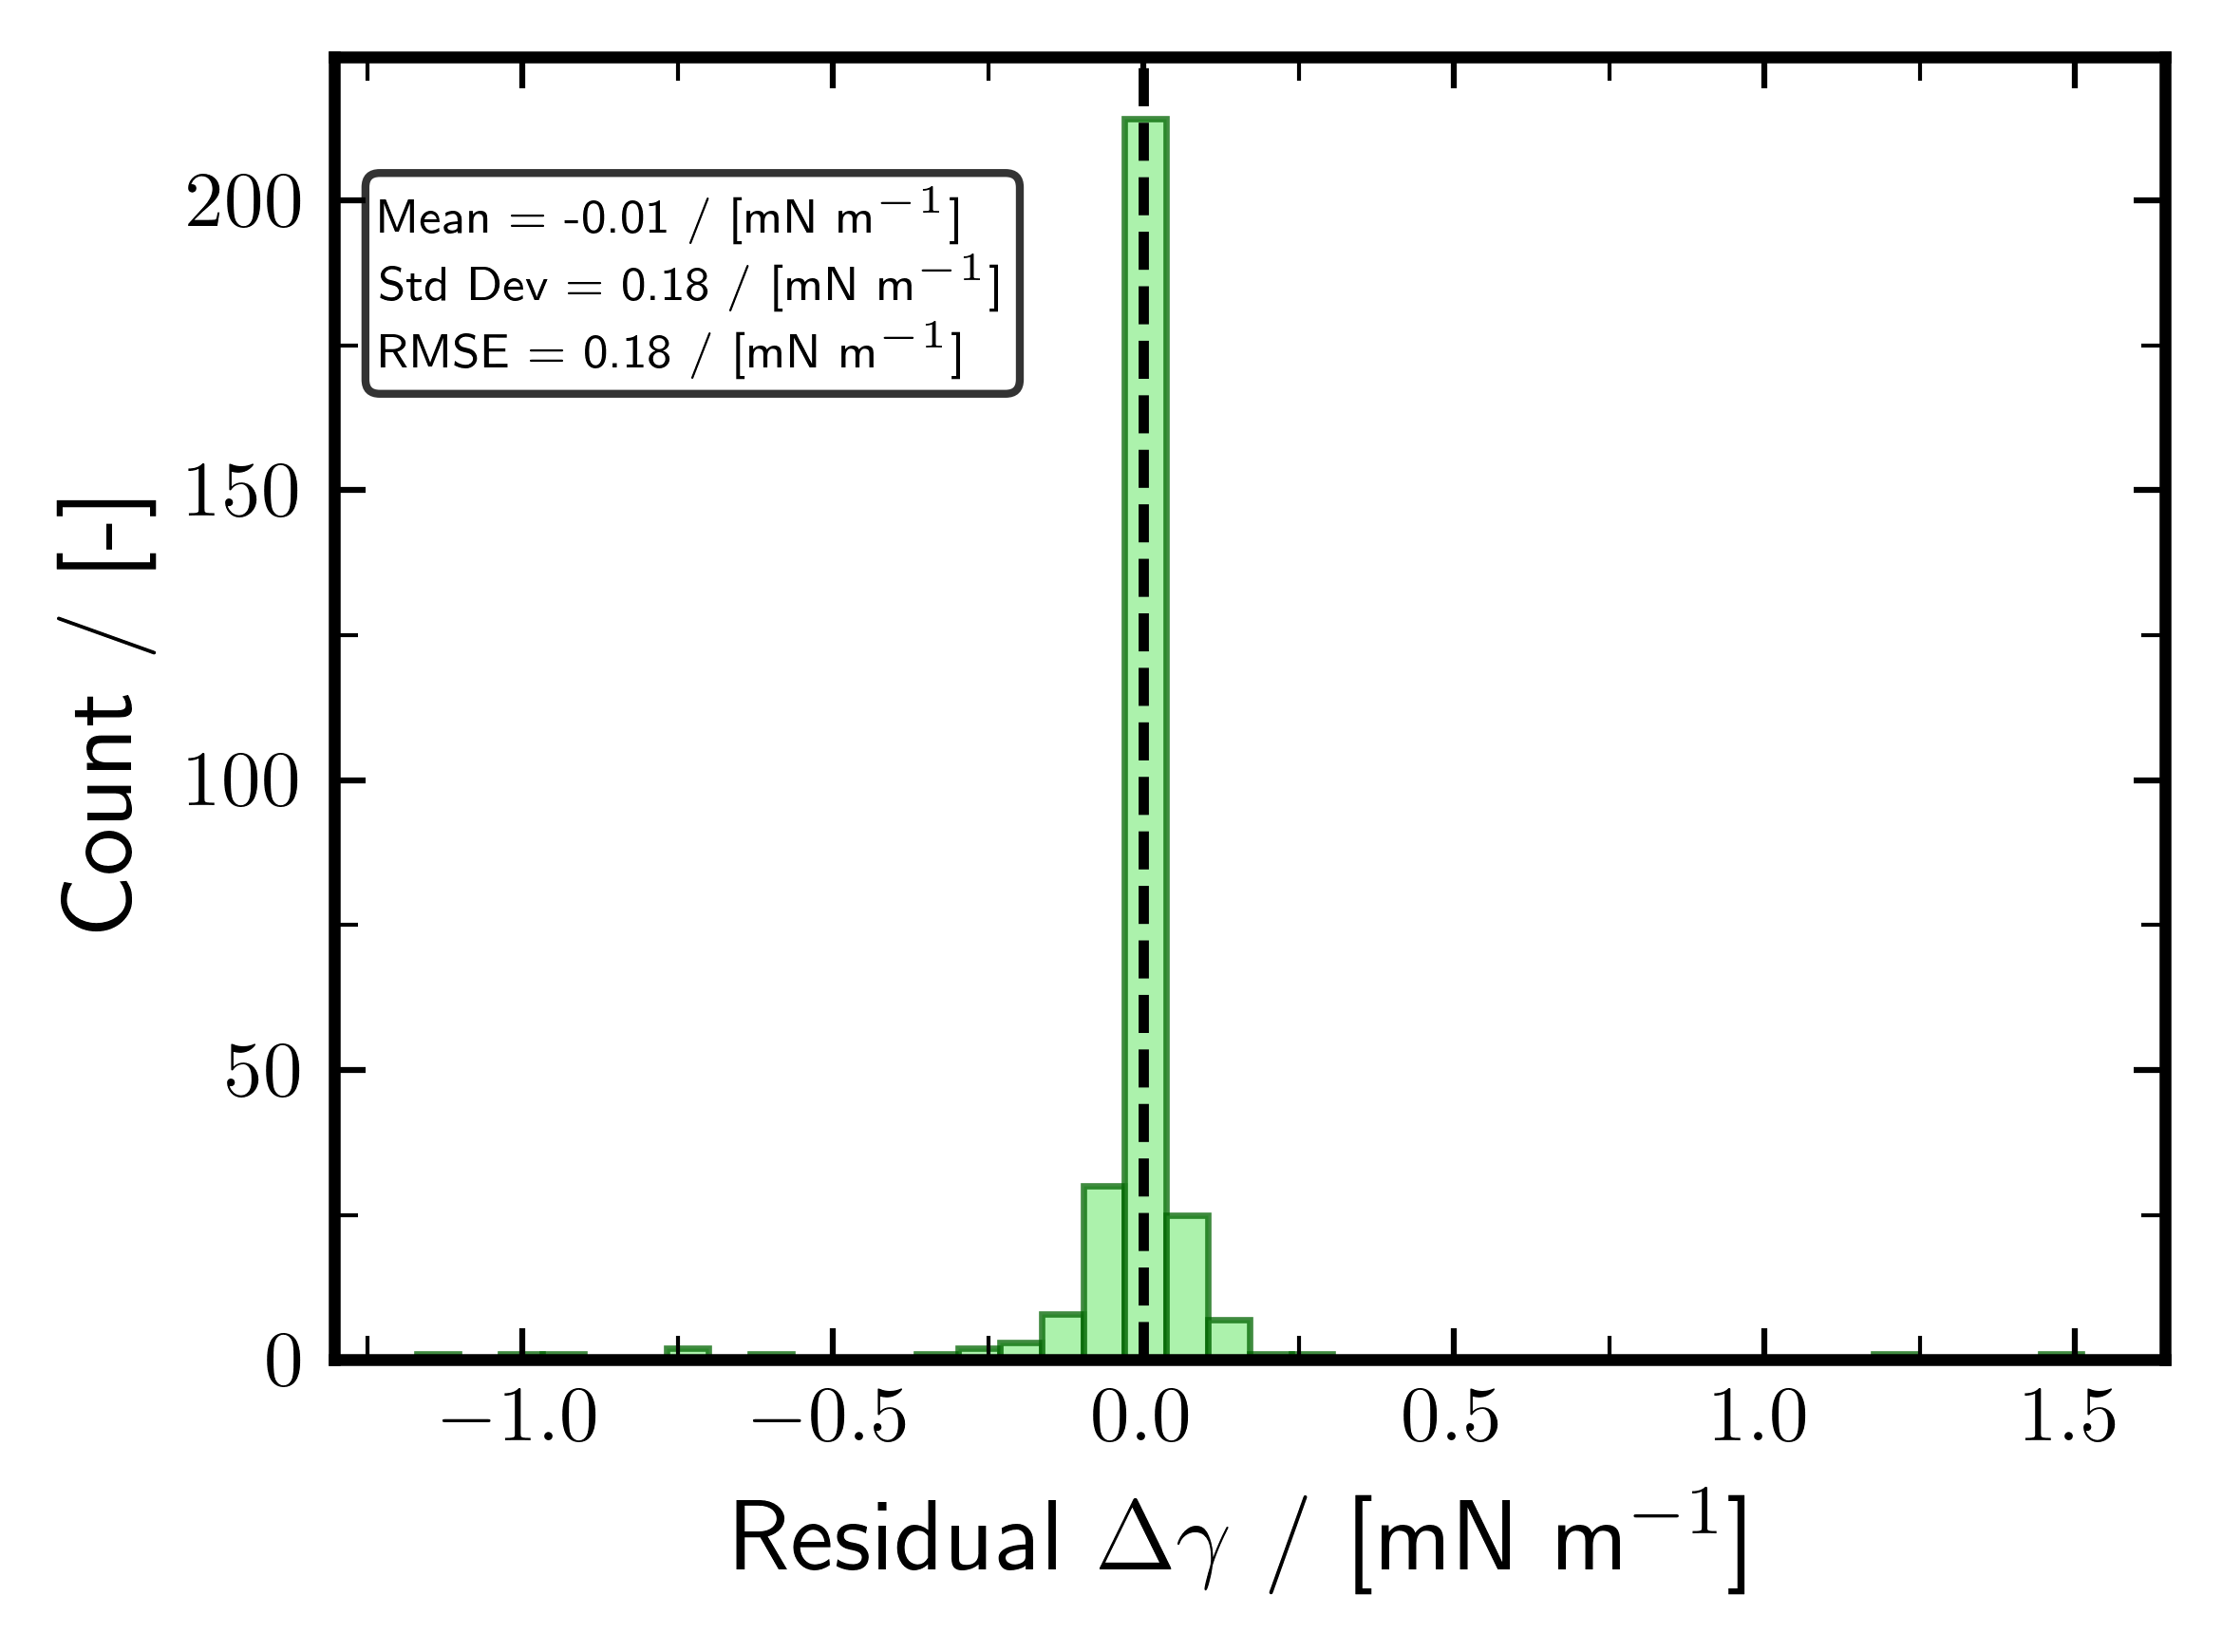

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $\\Delta\\gamma$ / [mN m$^{-1}$]', ylabel='Count / [-]'>)

In [15]:
# Residual distribution
post.plot_residual_distribution(save_path="GPR_gamma_residual_distribution", folder=OUTPUT_FOLDER)

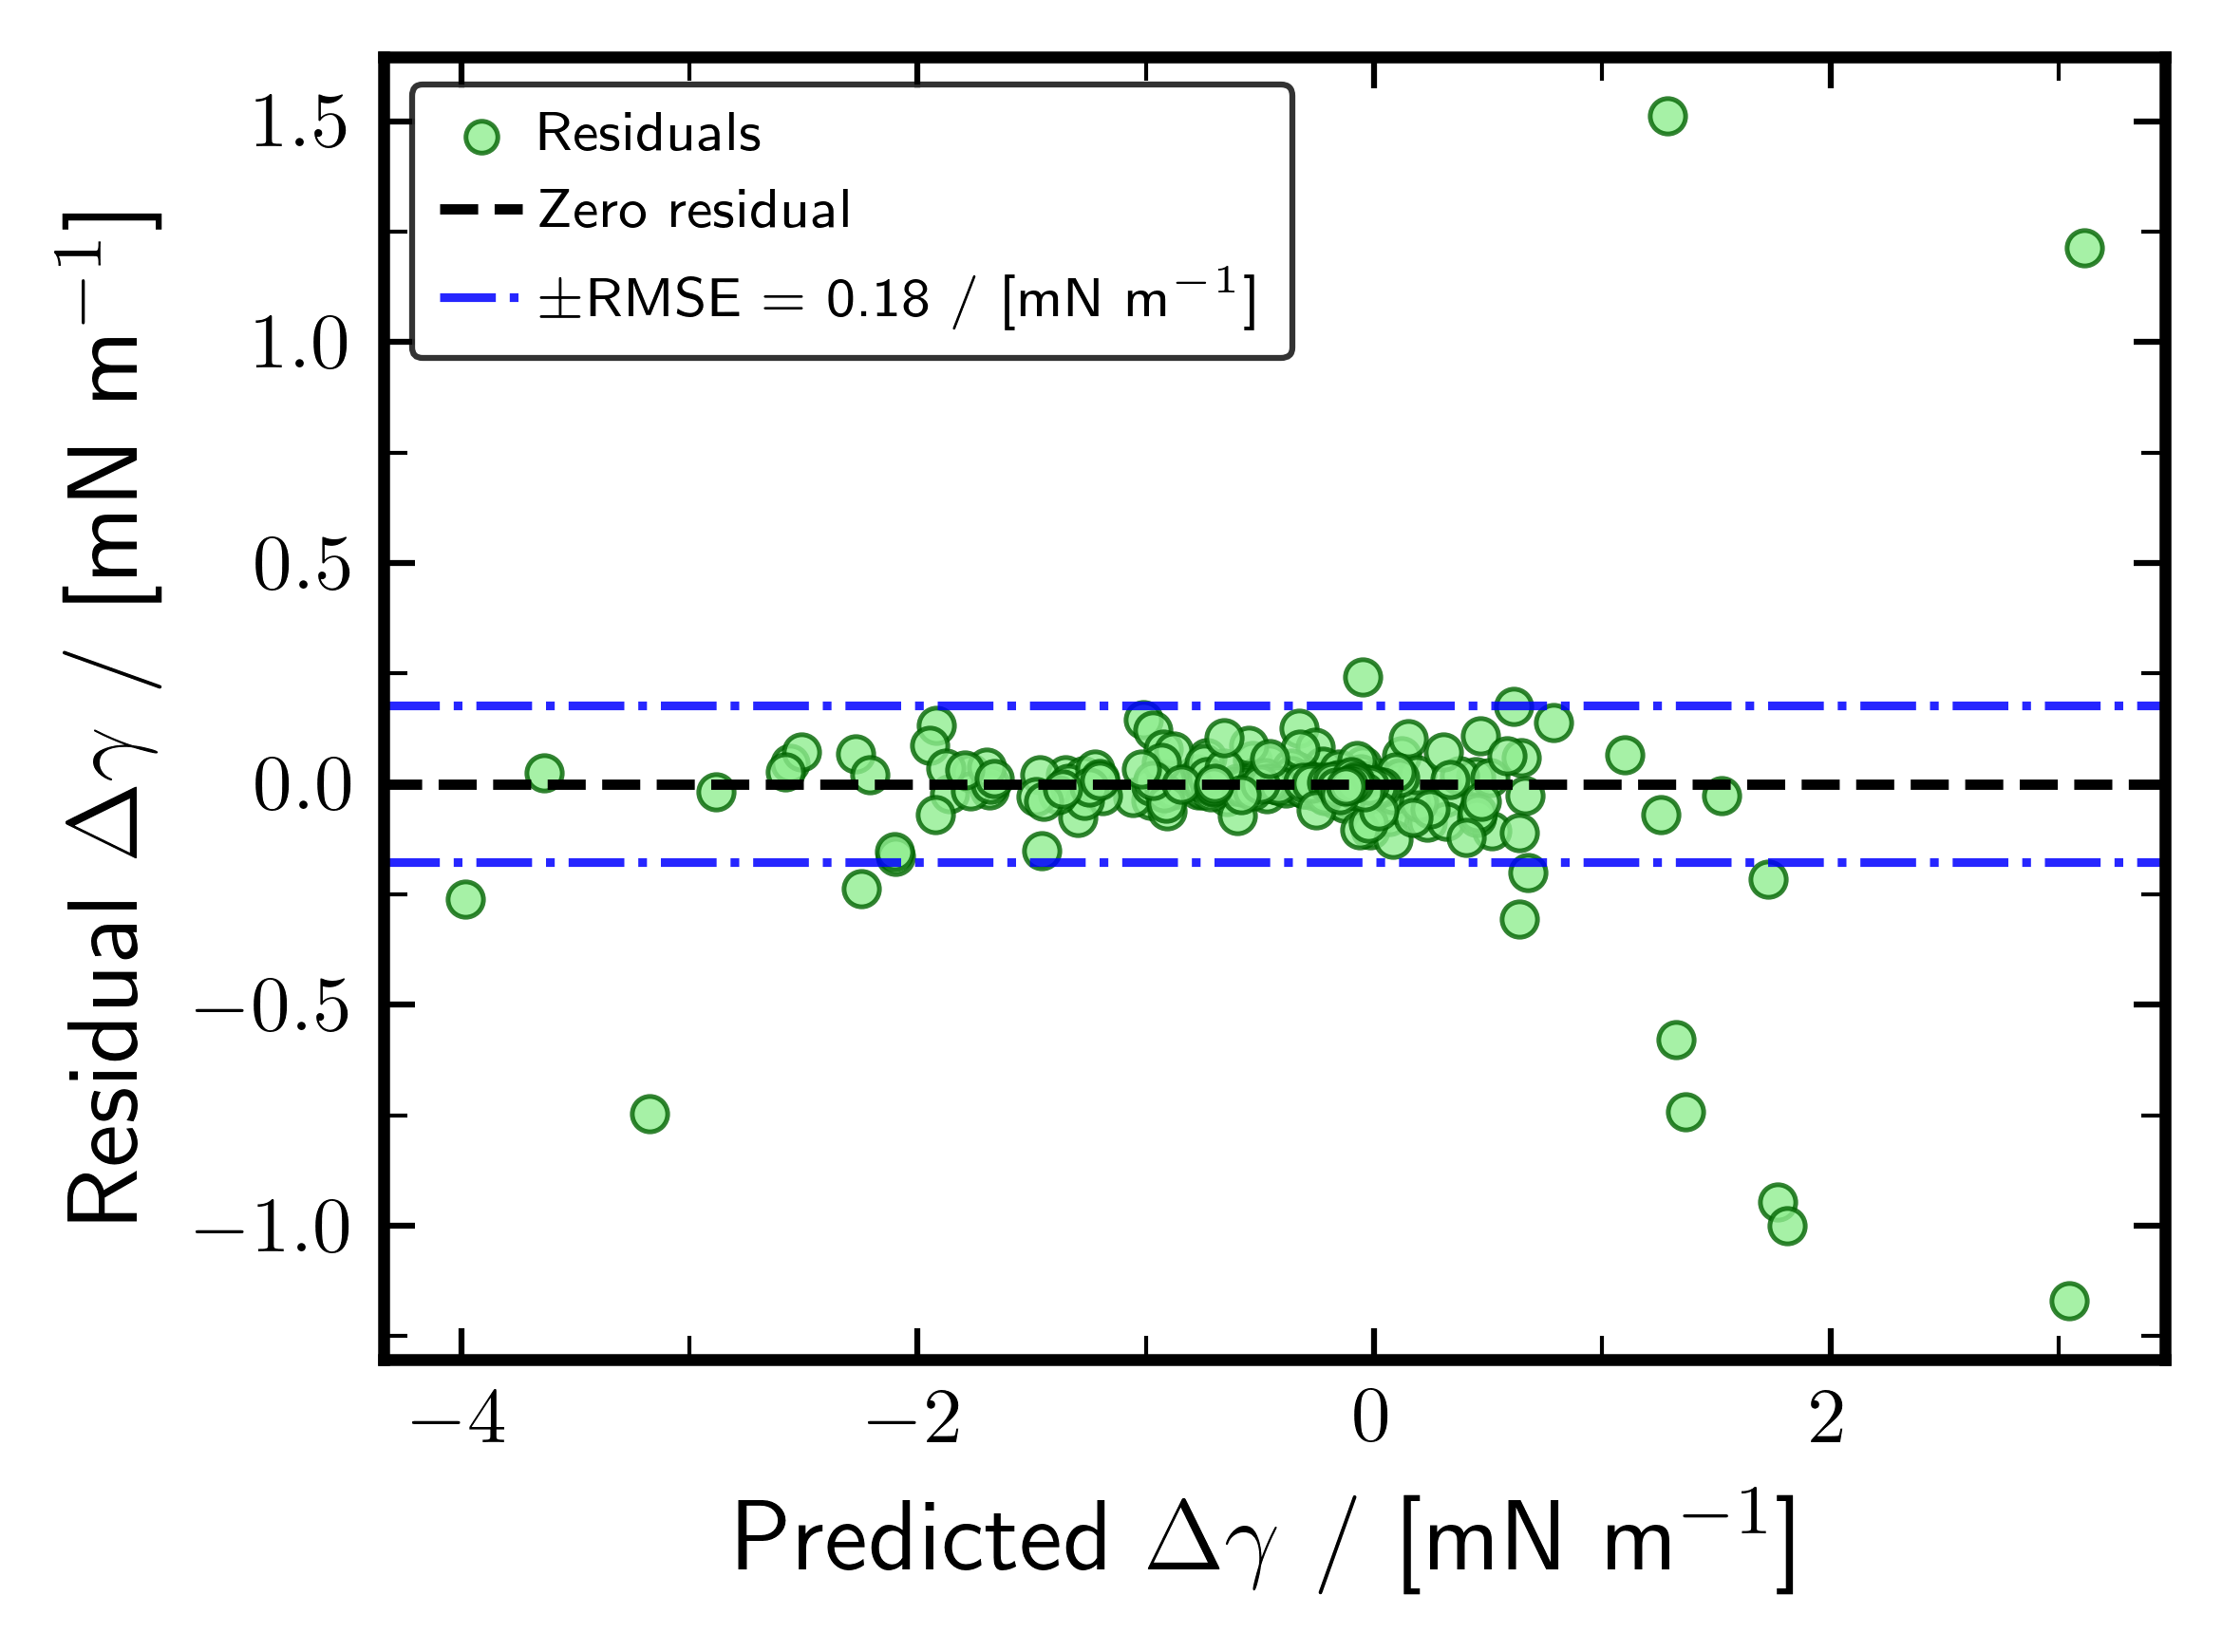

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Predicted $\\Delta\\gamma$ / [mN m$^{-1}$]', ylabel='Residual $\\Delta\\gamma$ / [mN m$^{-1}$]'>)

In [16]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="GPR_gamma_residual_vs_predicted", folder=OUTPUT_FOLDER)

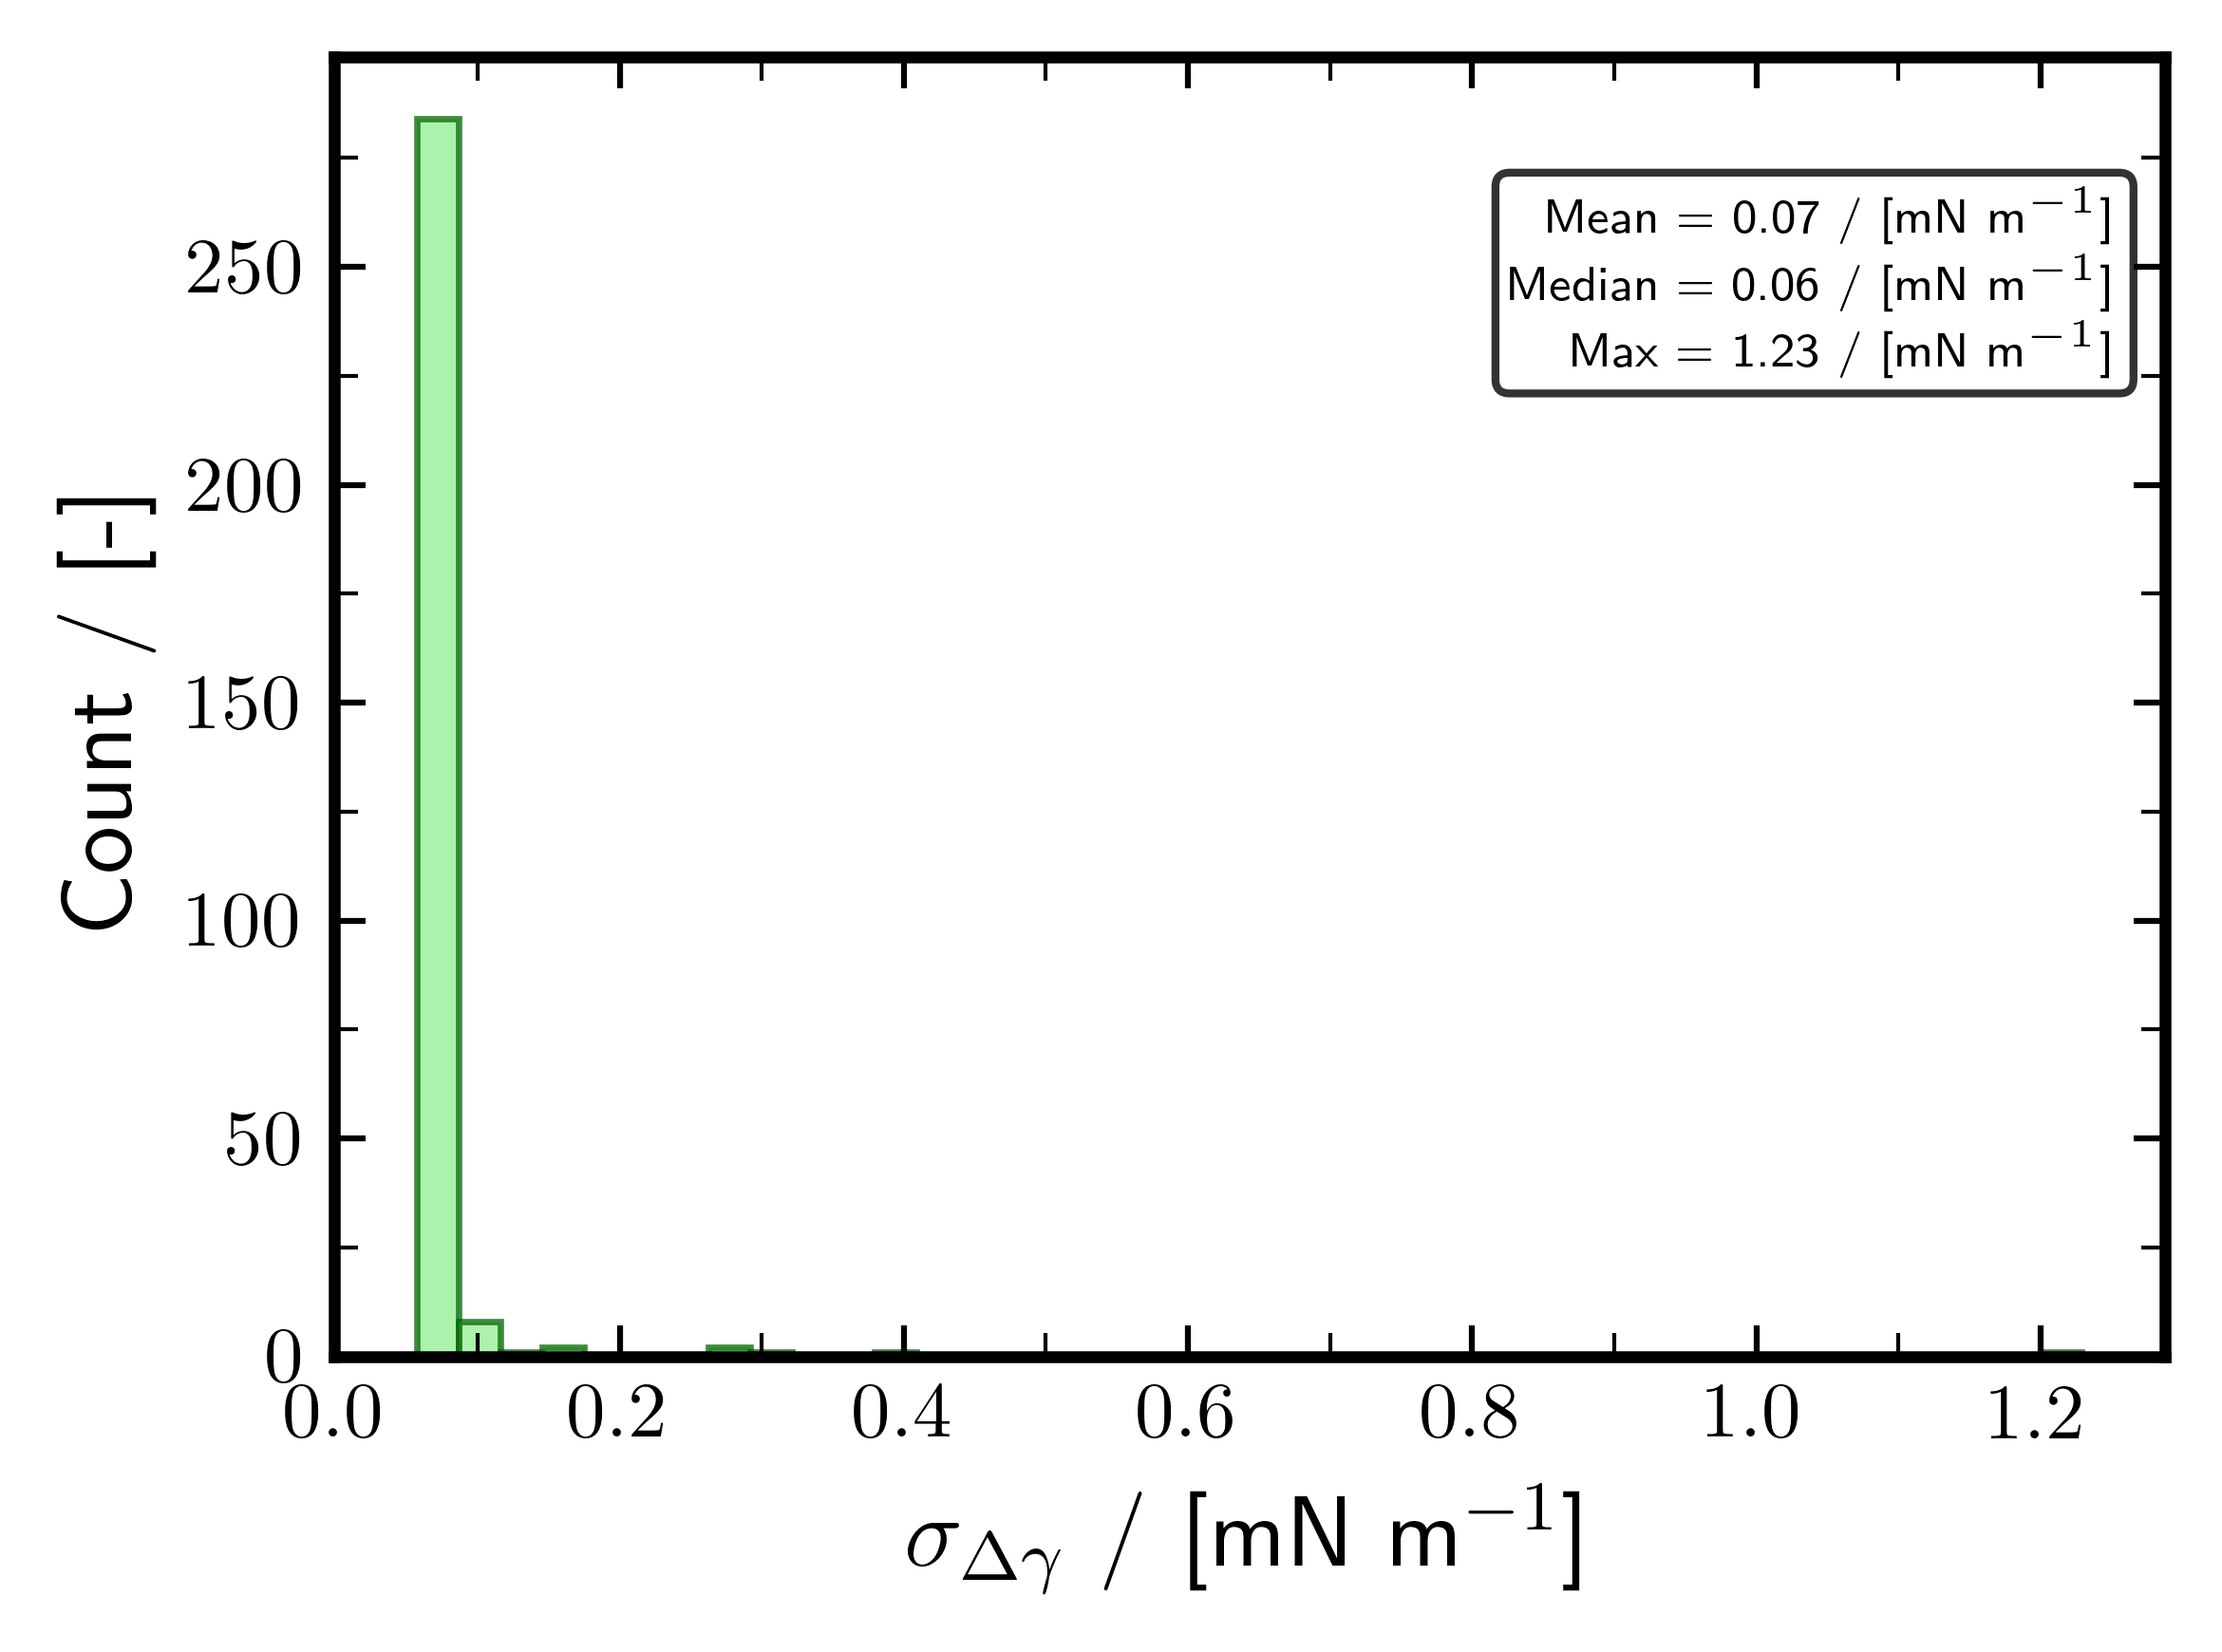

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\sigma_{\\Delta\\gamma}$ / [mN m$^{-1}$]', ylabel='Count / [-]'>)

In [17]:
# GPR: Predictive std histogram
post.plot_std_histogram(y_test_std, save_path="GPR_gamma_std_histogram", folder=OUTPUT_FOLDER)

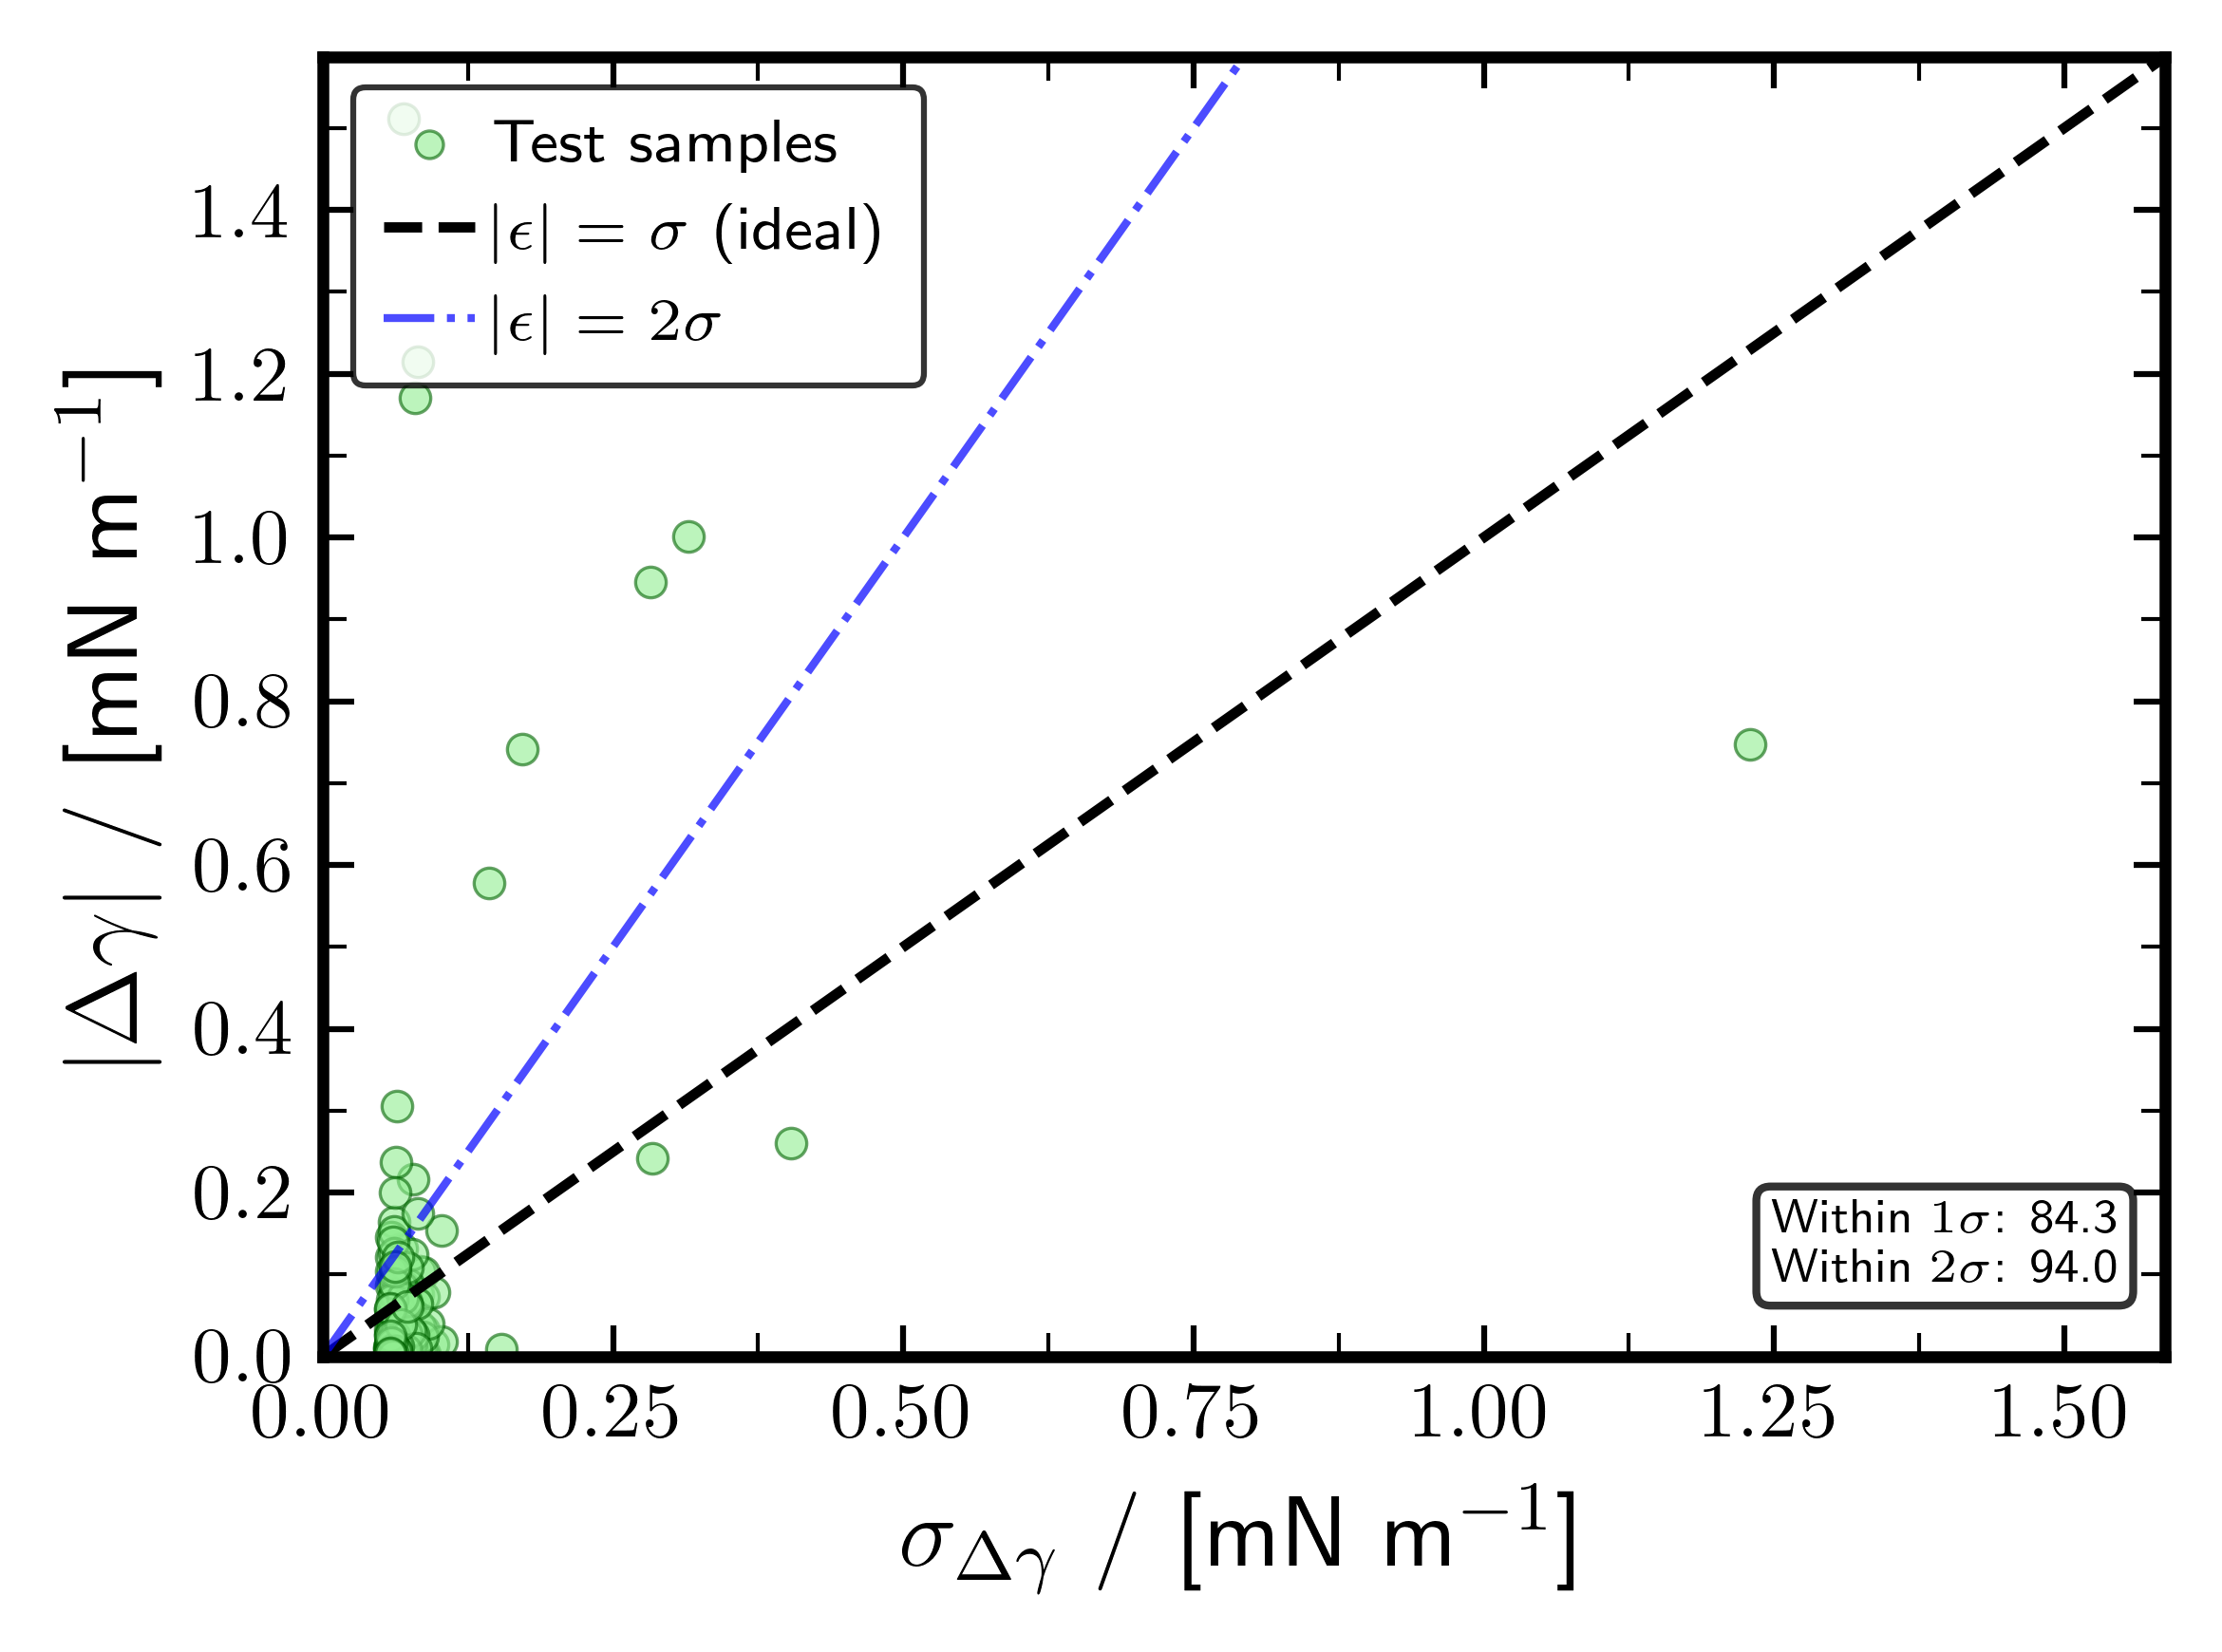

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\sigma_{\\Delta\\gamma}$ / [mN m$^{-1}$]', ylabel='$|\\Delta\\gamma|$ / [mN m$^{-1}$]'>)

In [18]:
# GPR: |error| vs predictive std (calibration)
post.plot_error_vs_std(y_test_std, save_path="GPR_gamma_error_vs_std", folder=OUTPUT_FOLDER)

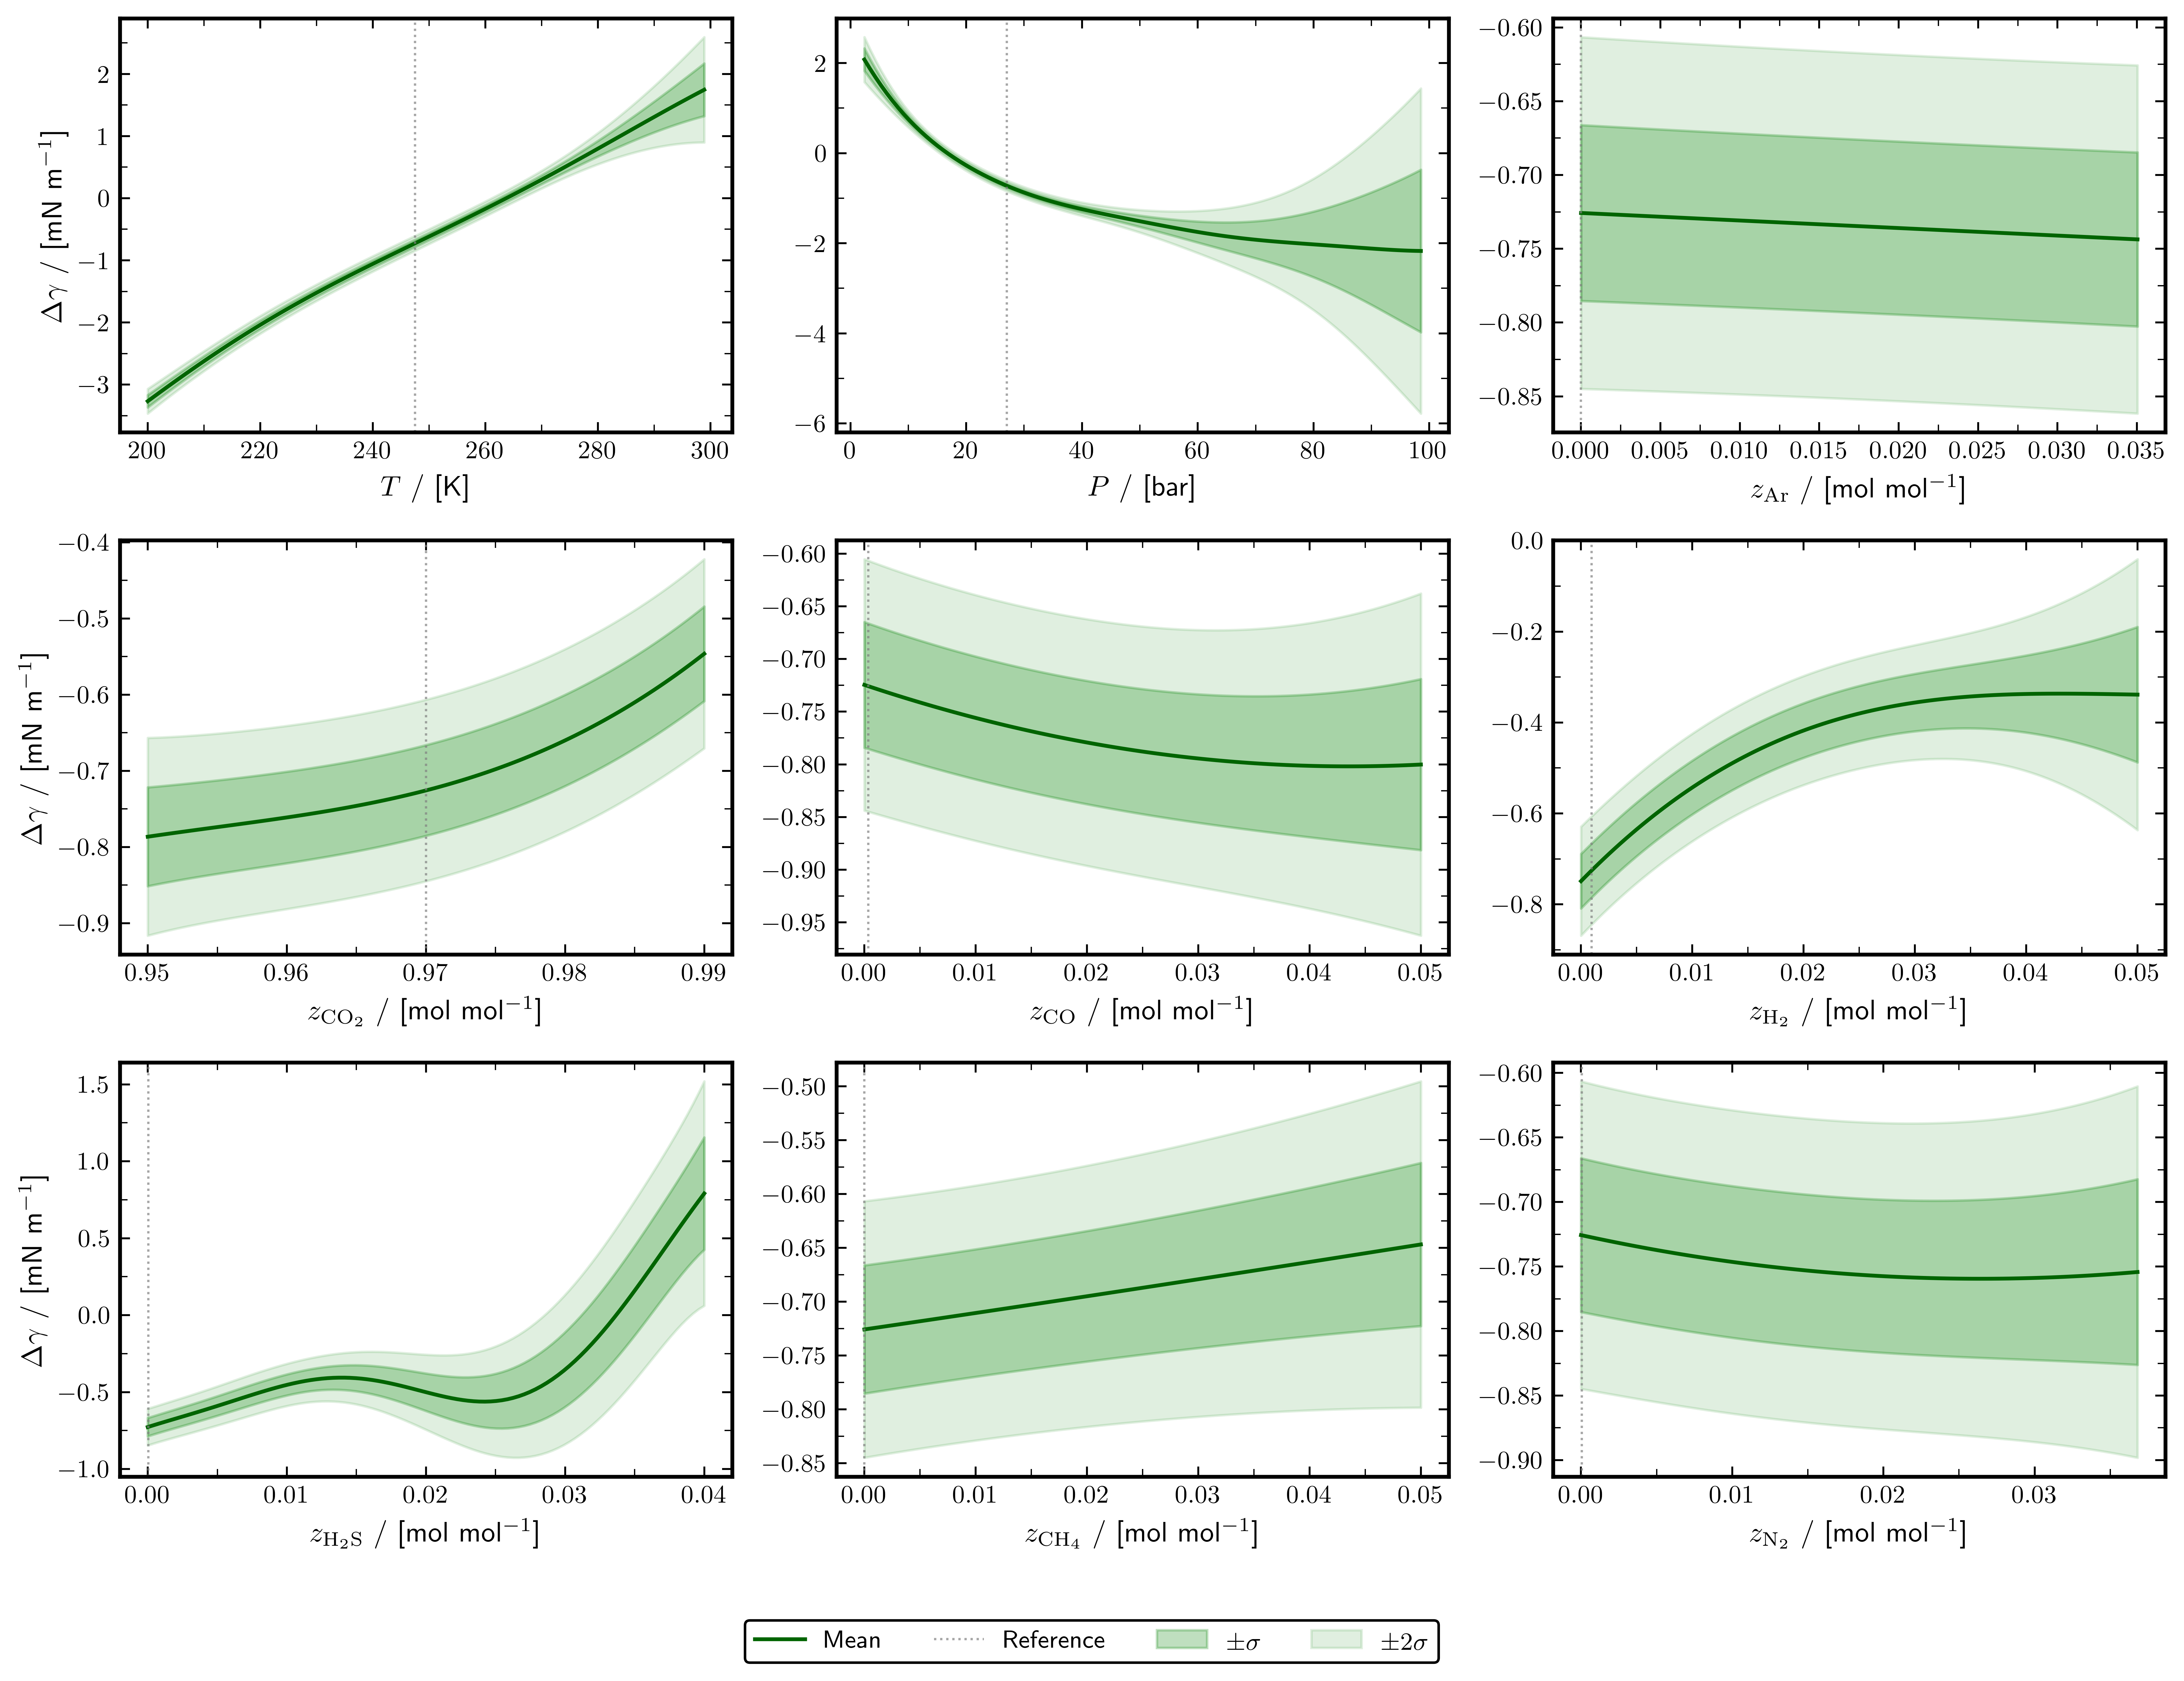

(<Figure size 7200x5400 with 9 Axes>,
 array([<Axes: xlabel='$T$ / [K]', ylabel='$\\Delta\\gamma$ / [mN m$^{-1}$]'>,
        <Axes: xlabel='$P$ / [bar]'>,
        <Axes: xlabel='$z_{\\mathrm{Ar}}$ / [mol mol$^{-1}$]'>,
        <Axes: xlabel='$z_{\\mathrm{CO_2}}$ / [mol mol$^{-1}$]', ylabel='$\\Delta\\gamma$ / [mN m$^{-1}$]'>,
        <Axes: xlabel='$z_{\\mathrm{CO}}$ / [mol mol$^{-1}$]'>,
        <Axes: xlabel='$z_{\\mathrm{H_2}}$ / [mol mol$^{-1}$]'>,
        <Axes: xlabel='$z_{\\mathrm{H_2S}}$ / [mol mol$^{-1}$]', ylabel='$\\Delta\\gamma$ / [mN m$^{-1}$]'>,
        <Axes: xlabel='$z_{\\mathrm{CH_4}}$ / [mol mol$^{-1}$]'>,
        <Axes: xlabel='$z_{\\mathrm{N_2}}$ / [mol mol$^{-1}$]'>],
       dtype=object))

In [19]:
# GPR: Response curves — saved individually per feature
X_ref = X_train.median().values
post.plot_response_curves(
    model               = gpr_model,
    X_ref               = X_ref,
    feature_names       = features,
    X_train             = X_train,
    n_points            = 100,
    return_std          = True,
    save_individually   = True,
    save_path           = "GPR_gamma_response",
    folder              = OUTPUT_FOLDER,
)

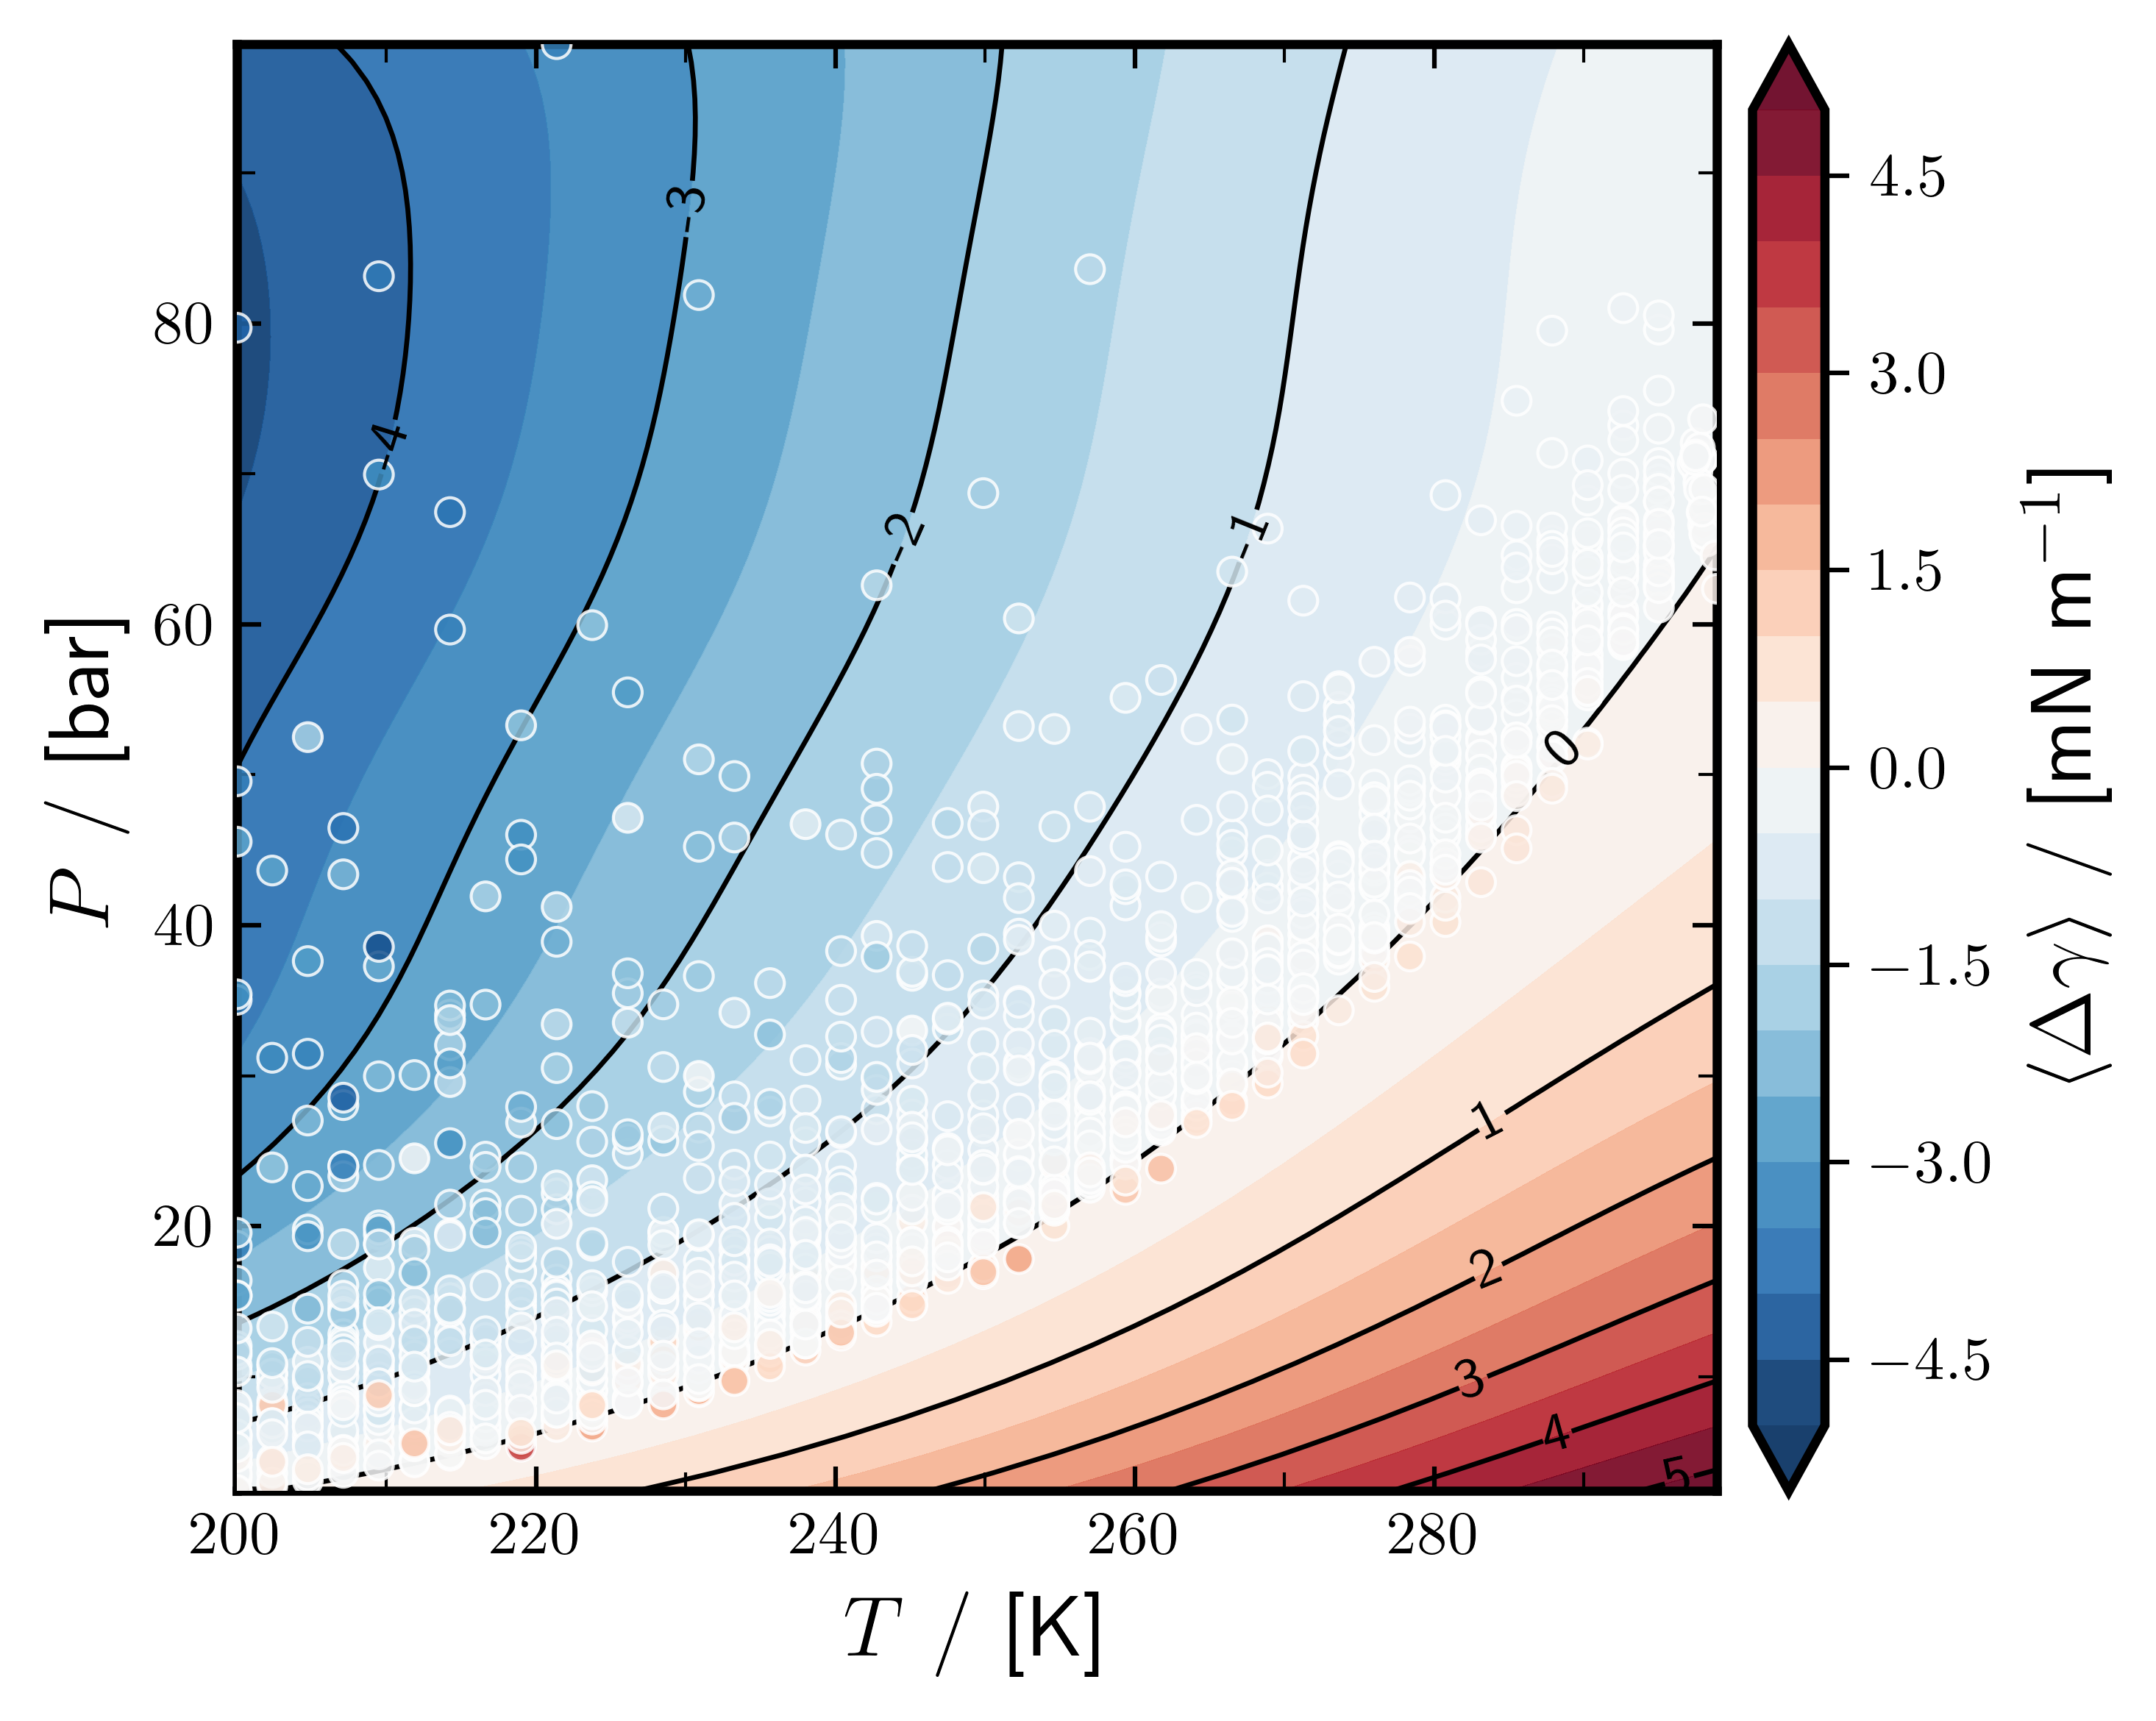

(<Figure size 3000x2400 with 2 Axes>,
 array([<Axes: xlabel='$T$ / [K]', ylabel='$P$ / [bar]'>], dtype=object))

In [20]:
# 2D Response Surface: T vs P (all z_* fixed at training median)
post.plot_2d_response_surface(
    model         = gpr_model,
    X_train       = X_train,
    y_train       = y_train,
    feature_names = features,
    T_name        = "T",
    P_name        = "P",
    n_grid        = 80,
    return_std    = False,
    save_path     = "GPR_2D_response_T_P",
    folder        = OUTPUT_FOLDER,
)


In [21]:
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
model_path = os.path.join(OUTPUT_FOLDER, "GPR_residual_model.joblib")
joblib.dump(gpr_model, model_path)
print(f"Model saved to: {model_path}")

Model saved to: GPR_RESIDUAL_OUTPUTS/GPR_residual_model.joblib


In [22]:
# Reconstruct full gamma_cDFT = gamma_base + residual_pred

gamma_base_train = df.loc[X_train.index, "gamma_base"].values
gamma_base_test  = df.loc[X_test.index,  "gamma_base"].values
gamma_base_val   = df.loc[X_val.index,   "gamma_base"].values

gamma_cDFT_train = df.loc[X_train.index, "gamma_cDFT"].values
gamma_cDFT_test  = df.loc[X_test.index,  "gamma_cDFT"].values
gamma_cDFT_val   = df.loc[X_val.index,   "gamma_cDFT"].values

gamma_pred_train = gamma_base_train + y_train_pred
gamma_pred_test  = gamma_base_test  + y_test_pred
gamma_pred_val   = gamma_base_val   + y_val_pred

# std carries through the additive reconstruction unchanged
print(f"Reconstructed gamma_cDFT  R² — train: {_r2(gamma_cDFT_train, gamma_pred_train):.4f} "
      f"| test: {_r2(gamma_cDFT_test, gamma_pred_test):.4f} "
      f"| val:  {_r2(gamma_cDFT_val,  gamma_pred_val):.4f}")

Reconstructed gamma_cDFT  R² — train: 0.9999 | test: 0.9990 | val:  0.9978


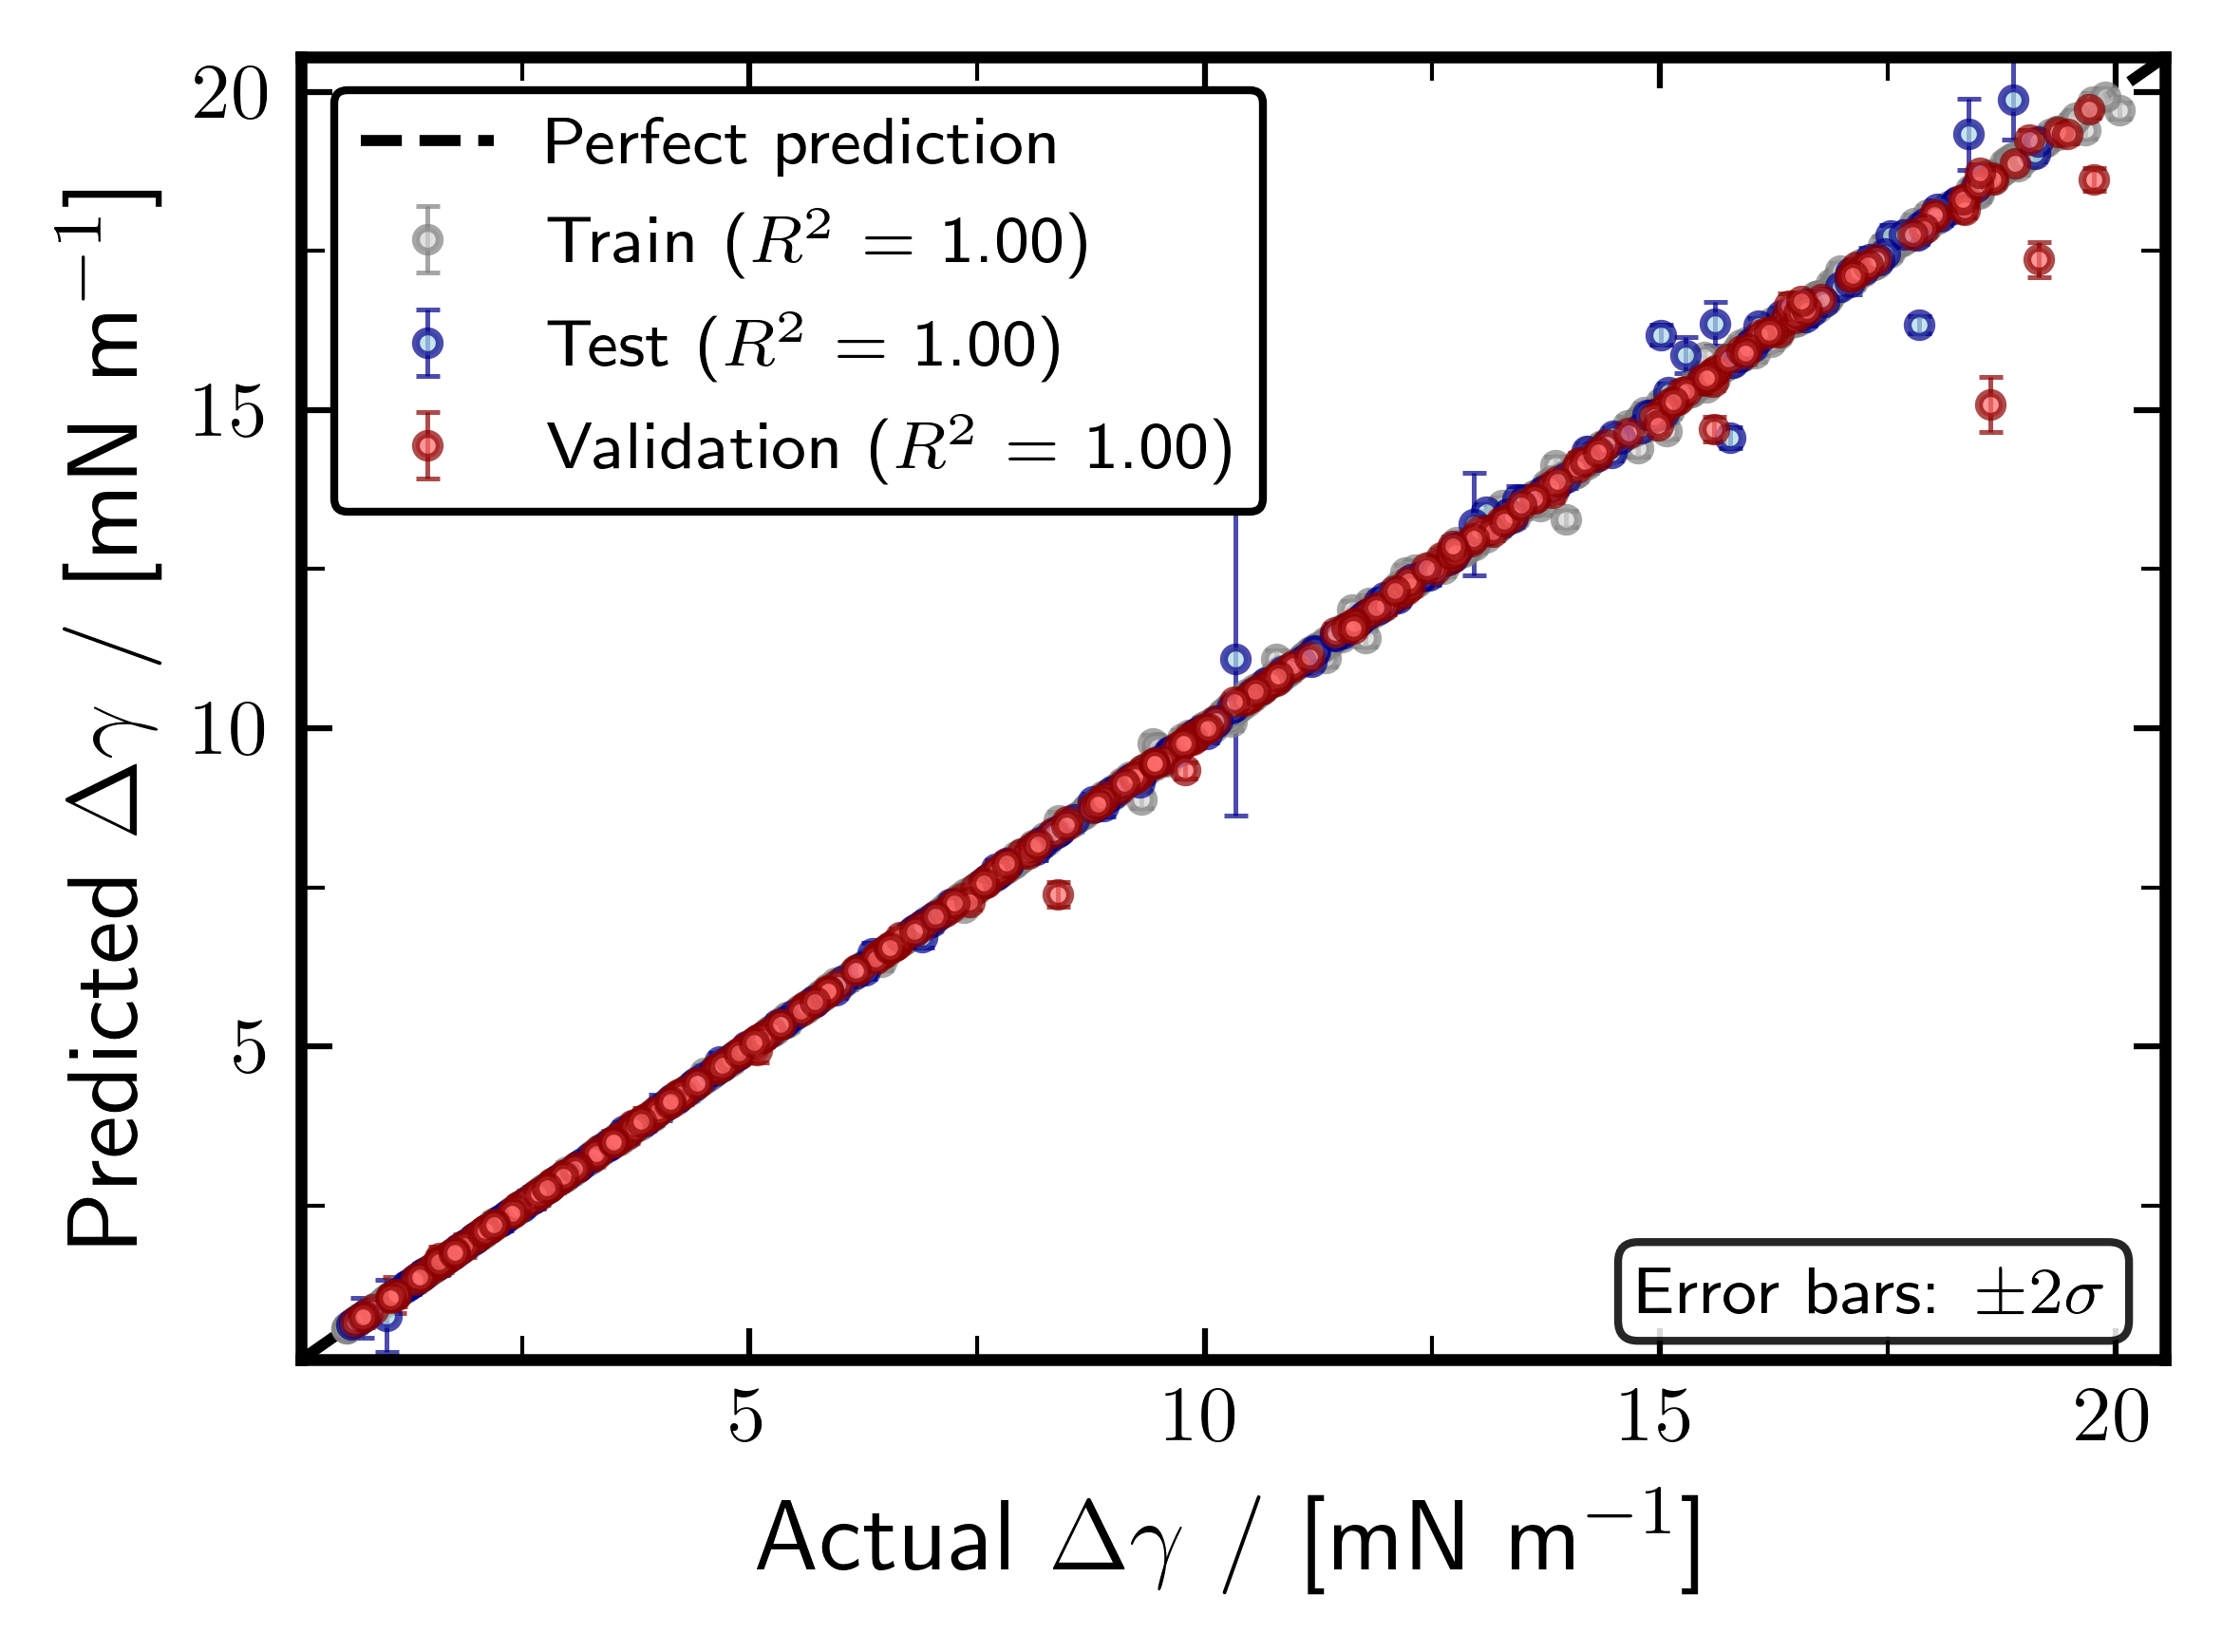

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $\\Delta\\gamma$ / [mN m$^{-1}$]', ylabel='Predicted $\\Delta\\gamma$ / [mN m$^{-1}$]'>)

In [23]:
# Parity plot: gamma_cDFT (actual) vs gamma_pred (reconstructed) with ±2σ uncertainty
post.plot_reconstructed_parity(
    datasets_reconstructed={
        "train": (gamma_cDFT_train, gamma_pred_train, y_train_std),
        "test":  (gamma_cDFT_test,  gamma_pred_test,  y_test_std),
        "val":   (gamma_cDFT_val,   gamma_pred_val,   y_val_std),
    },
    n_sigma=2.0,
    model_name="GPR",
    save_path="GPR_gamma_reconstructed_parity",
    folder=OUTPUT_FOLDER,
)

In [24]:
post.print_summary()

# Collect and save all metrics
if RUN_CV:
    metrics["cv_r2_scores"]   = cv_r2_scores.tolist()
    metrics["cv_r2_mean"]     = float(cv_r2_scores.mean())
    metrics["cv_r2_std"]      = float(cv_r2_scores.std())
    metrics["cv_rmse_scores"] = cv_rmse_scores.tolist()
    metrics["cv_rmse_mean"]   = float(cv_rmse_scores.mean())
    metrics["cv_rmse_std"]    = float(cv_rmse_scores.std())
else:
    metrics["cv_r2_scores"]   = []
    metrics["cv_r2_mean"]     = None
    metrics["cv_r2_std"]      = None
    metrics["cv_rmse_scores"] = []
    metrics["cv_rmse_mean"]   = None
    metrics["cv_rmse_std"]    = None

metrics["model"]                = "GPR_RBF"
metrics["kernel"]               = str(gpr_model.named_steps["gpr"].kernel_)
metrics["alpha"]                = gpr_model.named_steps["gpr"].alpha
metrics["n_restarts_optimizer"] = gpr_model.named_steps["gpr"].n_restarts_optimizer
metrics["features"]             = features
metrics["target"]               = target
metrics["seed"]                 = SEED

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"GPR_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - DELTA_GAMMA
Samples:        300
R² Score:       0.954657
RMSE:           0.176722
MAE:            0.056572
Mean Residual:  -0.012014
Std Residual:   0.176313

FEATURE IMPORTANCES:
------------------------------------------------------------
  P                         |  35.26% | █████████████████
  z_hydrogen_sulfide        |  27.83% | █████████████
  T                         |  20.22% | ██████████
  z_carbon_dioxide          |   7.89% | ███
  z_hydrogen                |   4.81% | ██
  z_carbon_monoxide         |   1.74% | 
  z_nitrogen                |   1.61% | 
  z_methane                 |   0.59% | 
  z_argon                   |   0.05% | 

Metrics saved to: GPR_RESIDUAL_OUTPUTS/GPR_residual_metrics.json


In [25]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 2.69 minutes
